# Curriculum Learning CTG-Net — Multi-Task (CORAL + Severe Aux) + Threshold Calibration

**Objective:** Statistically defensible 3-class CTG classification via two-stage curriculum learning with ordinal regression and auxiliary severe detection.

**Pipeline Summary:**
- **Stage 1 (Pretrain):** Train on Step 2 labels (30–60 min) — broad temporal context
- **Stage 2 (Fine-tune):** Fine-tune on Step 3 labels (last 30 min) — delivery-proximate features
- **Evaluation:** Record-level prediction via window aggregation + calibrated thresholds

**Architecture:**
- Shared CTG-Net backbone → Global Average Pool →
  - **CORAL head** (2 logits): ordinal regression encoding Normal < Mild < Severe
  - **Severe head** (1 logit): binary Severe-vs-Rest with weighted BCE
- Combined loss: `L = L_coral + λ * BCE(severe_logit, y==2)`

**Key Design Choices:**
1. **Multi-task loss** — CORAL handles rank structure, auxiliary head explicitly learns Severe features
2. **Weighted BCE only on aux head** — avoids warping CORAL ordinal thresholds
3. **Threshold calibration** — grid-search (t1, t2) on val fold to optimize macro-F1 with Severe recall constraint
4. **More aggressive fine-tuning** — 4 blocks unfrozen, LR=1e-4 (was 2 blocks, 3e-5)
5. **Denser windows** — stride 300 (5 min) for training

**Leakage Prevention:**
- StratifiedKFold by record_id
- Normalization from train fold only
- Threshold calibration on val fold only (carved from train)
- All assertions enforced per fold

## 1. Imports

In [19]:
# Core
import numpy as np
import pandas as pd
from pathlib import Path
import wfdb
import json
import warnings
from datetime import datetime
from collections import defaultdict

# Sklearn
from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, train_test_split
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import (
    Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, GlobalAveragePooling2D, Dense, Concatenate,
    Reshape, Multiply, Add,                  # NEW — for SE + residual
)
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
warnings.filterwarnings('ignore')

print(f"TensorFlow {tf.__version__} | NumPy {np.__version__}")


TensorFlow 2.16.1 | NumPy 1.26.4


## 2. Configuration & Toggles

All experiment parameters in one place. Change `CFG` values to toggle aggregation method, ordinal vs softmax, number of unfrozen blocks, k-fold/repeats, etc.

In [20]:

# ======================= PATHS =======================
RAW_DATASET   = Path("../data/raw_dataset")
STEP2_LABELS  = Path("../ExpertAnnotations/step2_labels.csv")
STEP3_LABELS  = Path("../ExpertAnnotations/step3_labels.csv")
EXPERT_RAW    = Path("../ExpertAnnotations/ExpertAnnCTU-UHB-CTG_20150203 (1).xls")
OUTPUT_DIR    = Path("outputs/curriculum")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ===================== SIGNAL ========================
SAMPLING_RATE   = 4       # Hz original
TARGET_FS       = 1       # Hz after downsample
WINDOW_LEN      = 1800    # samples  (30 min @ 1 Hz)
TEST_STRIDE     = 450     # sliding-window stride for test  (7.5 min)

# ==================== LABELS =========================
NUM_CLASSES     = 3
CLASS_NAMES     = ["Normal", "Mild", "Severe"]
LABEL_MAP       = {1: 0, 2: 1, 3: 2}   # raw majority-vote → 0-indexed

# ============== CV / EXPERIMENT TOGGLES ==============
CFG = dict(
    # --- Cross-validation ---
    n_splits         = 5,
    n_repeats        = 1,
    cv_seed          = 42,
    val_ratio        = 0.20,

    # --- Stage 1 (pretrain on step2) ---
    s1_epochs        = 15,
    s1_lr            = 1e-3,
    s1_batch         = 16,
    s1_patience      = 5,
    s1_augment       = True,
    s1_noise         = 0.05,
    s1_train_stride  = 300,

    # --- Stage 2 (fine-tune on step3) ---
    s2_epochs        = 80,
    s2_lr            = 1e-4,
    s2_batch         = 8,
    s2_patience      = 25,
    s2_weight_decay  = 1e-4,
    s2_augment       = True,
    s2_noise         = 0.03,
    s2_train_stride  = 300,
    unfreeze_blocks  = 4,
    severe_boost     = 1.0,
    mild_boost       = 1.0,

    # --- Two-boundary heads ---
    use_two_boundary   = True,
    boundary_lambda_a  = 1.0,
    boundary_lambda_b  = 0.8,       # ← reduced from 2.0 to stop Mild→Severe promotion
    boundary_b_pos_cap = 3.0,       # ← reduced from 5.0 to limit Boundary-B pressure
    default_tA         = 0.5,
    default_tB         = 0.5,

    # --- Gray-zone margin decoding ---
    use_margin_decoding = False,
    default_margin      = 0.05,

    # --- Balanced sampling ---
    balanced_sampling      = True,
    severe_oversample      = 2,         # Stage 1 oversample (reduced from 3)
    s2_severe_oversample   = 1,         # Stage 2 oversample (reduced from 2 — no duplication)
    mild_oversample        = 2,         # NEW: also oversample Mild to balance classes
    s2_mild_oversample     = 2,         # NEW: Mild oversample in Stage 2

    # --- Engineered channel (slow-slope) ---
    use_delta_channels   = False,
    use_slow_slope       = True,
    slow_slope_lag       = 30,
    n_input_channels     = 3,

    # --- Legacy flags (disabled) ---
    use_coral        = False,
    use_severe_aux   = False,
    severe_lambda    = 0.7,
    severe_pos_cap   = 5.0,

    # --- Constrained early stopping ---
    es_norm_floor      = 0.55,
    es_sev_floor       = 0.45,
    es_penalty_alpha   = 1.5,
    es_penalty_beta    = 1.0,

    # --- Soft-penalty threshold calibration ---
    calibrate_thresholds = True,
    calib_metric         = "macro_f1",
    calib_severe_floor   = 0.45,
    calib_normal_floor   = 0.60,
    calib_grid_tA        = [0.40, 0.45, 0.50, 0.55, 0.60],
    calib_grid_tB        = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90],  # ← widened upward
    calib_grid_m         = [0.00, 0.03, 0.05, 0.07, 0.10],
    calib_n_splits       = 2,
    calib_base_seed      = 100,

    # --- Aggregation ---
    aggregation      = "mean_logits",
    top_k            = 5,

    # --- Architecture (CTG-Net v2: wider + SE + residual) ---
    temporal_filters    = 32,
    temporal_kernel     = 5,
    depth_multiplier    = 2,
    separable_filters   = 32,
    separable_kernels   = [3, 7, 15],
    projection_filters  = 32,
    dropout_rate        = 0.35,
    use_depthwise       = True,

    # --- On-the-fly augmentation ---
    aug_jitter_std   = 0.05,
    aug_scale_range  = 0.2,
    aug_shift_max    = 100,
    aug_enabled_s1   = True,
    aug_enabled_s2   = True,

    # --- Soft labels from expert votes (Item 3) ---
    use_soft_labels  = False,      # disabled — dilutes severe signal

    # --- Seed ensemble (NEW — Item 4) ---
    n_ensemble_seeds   = 3,                    # number of models per fold
    ensemble_seeds     = [42, 123, 2024],      # random seeds for each model
)

print("Configuration ready — Run H: soft labels + seed ensemble")
print(f"  Architecture: temp_f={CFG['temporal_filters']}, sep_f={CFG['separable_filters']}, "
      f"proj_f={CFG['projection_filters']}, dropout={CFG['dropout_rate']}")
print(f"  Augmentation: jitter={CFG['aug_jitter_std']}, scale=±{CFG['aug_scale_range']}, "
      f"shift=±{CFG['aug_shift_max']}")
print(f"  λ_b={CFG['boundary_lambda_b']}, S1 OS={CFG['severe_oversample']}, "
      f"S2 OS={CFG['s2_severe_oversample']}")
print(f"  ES constraints: norm≥{CFG['es_norm_floor']}, sev≥{CFG['es_sev_floor']}")
print(f"  Soft labels: {CFG['use_soft_labels']}")
print(f"  Seed ensemble: {CFG['n_ensemble_seeds']} seeds {CFG['ensemble_seeds']}")
for k, v in CFG.items():

    print(f"  {k}: {v}")

Configuration ready — Run H: soft labels + seed ensemble
  Architecture: temp_f=32, sep_f=32, proj_f=32, dropout=0.35
  Augmentation: jitter=0.05, scale=±0.2, shift=±100
  λ_b=0.8, S1 OS=2, S2 OS=1
  ES constraints: norm≥0.55, sev≥0.45
  Soft labels: False
  Seed ensemble: 3 seeds [42, 123, 2024]
  n_splits: 5
  n_repeats: 1
  cv_seed: 42
  val_ratio: 0.2
  s1_epochs: 15
  s1_lr: 0.001
  s1_batch: 16
  s1_patience: 5
  s1_augment: True
  s1_noise: 0.05
  s1_train_stride: 300
  s2_epochs: 80
  s2_lr: 0.0001
  s2_batch: 8
  s2_patience: 25
  s2_weight_decay: 0.0001
  s2_augment: True
  s2_noise: 0.03
  s2_train_stride: 300
  unfreeze_blocks: 4
  severe_boost: 1.0
  mild_boost: 1.0
  use_two_boundary: True
  boundary_lambda_a: 1.0
  boundary_lambda_b: 0.8
  boundary_b_pos_cap: 3.0
  default_tA: 0.5
  default_tB: 0.5
  use_margin_decoding: False
  default_margin: 0.05
  balanced_sampling: True
  severe_oversample: 2
  s2_severe_oversample: 1
  mild_oversample: 2
  s2_mild_oversample: 2
  u

## 3. Data Loading & Preprocessing Utilities

In [21]:
def load_labels(step2_path, step3_path):
    """Load and merge Step 2 / Step 3 labels, filtering uninterpretable (-1)."""
    s2 = pd.read_csv(step2_path)
    s3 = pd.read_csv(step3_path)
    s2 = s2[s2['Majority_Vote_Label'] != -1].copy()
    s3 = s3[s3['Majority_Vote_Label'] != -1].copy()
    s2['class_id'] = s2['Majority_Vote_Label'].map(LABEL_MAP)
    s3['class_id'] = s3['Majority_Vote_Label'].map(LABEL_MAP)
    s2['rec_id'] = s2['rec_id'].astype(str)
    s3['rec_id'] = s3['rec_id'].astype(str)
    return s2, s3


def remove_trailing_zeros(signal):
    """Remove trailing zeros from a signal."""
    sig = list(signal) if isinstance(signal, np.ndarray) else list(signal)
    i = len(sig) - 1
    while i >= 0 and sig[i] == 0:
        i -= 1
    return sig[:i + 1]


def downsample(signal, orig_fs=4, target_fs=1):
    """Downsample signal from orig_fs to target_fs."""
    return signal[::orig_fs // target_fs]


def gap_fill(signal):
    """Linear interpolation over zero-gaps."""
    s = np.array(signal, dtype=float)
    valid = np.where(s != 0)[0]
    if len(valid) == 0 or len(valid) == len(s):
        return s
    return np.interp(np.arange(len(s)), valid, s[valid])


def smooth(signal, k=5):
    """Moving-average smoothing."""
    s = np.array(signal, dtype=float)
    if len(s) < k:
        return s
    return np.convolve(s, np.ones(k) / k, mode='same')


def preprocess_signal(signal, augment=False, noise_level=0.05):
    """Gap-fill → smooth → (optional) Gaussian noise augmentation."""
    s = gap_fill(signal)
    s = smooth(s)
    if augment:
        s = s + np.random.normal(0, noise_level * max(np.std(s), 1e-6), len(s))
    return s


def load_raw_signals(dataset_path):
    """Load all CTG records → dict[rec_id] = {'FHR': ..., 'UC': ..., 'length': ...}."""
    records = [p.stem for p in dataset_path.glob("*.hea")]
    print(f"Found {len(records)} .hea files")
    data = {}
    for rid in records:
        try:
            rec = wfdb.rdrecord(str(dataset_path / rid))
            fhr = remove_trailing_zeros(rec.p_signal[:, 0].tolist())
            uc  = remove_trailing_zeros(rec.p_signal[:, 1].tolist())
            fhr = downsample(fhr, orig_fs=SAMPLING_RATE, target_fs=TARGET_FS)
            uc  = downsample(uc,  orig_fs=SAMPLING_RATE, target_fs=TARGET_FS)
            data[rid] = {'FHR': fhr, 'UC': uc, 'length': len(fhr)}
        except Exception as e:
            print(f"  skip {rid}: {e}")
    print(f"Loaded {len(data)} signals")
    return data


print("Data loading & preprocessing utilities defined")

Data loading & preprocessing utilities defined


## 4. Window Generation (Leakage-Proof)

`make_windows()` receives an explicit set of `record_ids` and only touches those records.
- `segment="step2"` → single 30–60 min window, `step2_label`
- `segment="step3"` → single last-30-min window, `step3_label`
- `segment="step2_sliding"` → overlapping sliding windows over first 60 min, `step2_label` (training)
- `segment="step3_sliding"` → overlapping sliding windows over last 60 min, `step3_label` (training)
- `segment="test_sliding"` → overlapping sliding windows over the full signal, `step3_label`

**Leakage guard:** window record-IDs are asserted to be a subset of the provided set at the call site.

In [22]:
def _extract_step2(signal, fs=1):
    """Extract the 30–60 min window (samples 1800..3600 at 1 Hz)."""
    start, end = 30 * 60 * fs, 60 * 60 * fs
    return signal[start:end] if len(signal) >= end else None


def _extract_step3(signal, win_min=30, fs=1):
    """Extract the last 30 min of the signal."""
    n = win_min * 60 * fs
    return signal[-n:] if len(signal) >= n else None


def _sliding_windows_from_region(fhr, uc, start, end, window_len, stride):
    """
    Generate overlapping (FHR, UC) windows within signal[start:end].
    Returns list of (fhr_window, uc_window) tuples.
    """
    seg_len = end - start
    if seg_len < window_len:
        return []
    windows = []
    for s in range(start, end - window_len + 1, stride):
        windows.append((fhr[s:s + window_len], uc[s:s + window_len]))
    if not windows:  # fallback: last possible window
        windows.append((fhr[end - window_len:end], uc[end - window_len:end]))
    return windows


def _slow_slope(signal, lag):
    """
    Compute slow-slope feature: dS(t) = S(t) - S(t - lag).
    Clinically meaningful deceleration ramp detector.
    First `lag` samples are set to 0 (no look-back available).
    """
    s = np.asarray(signal, dtype=np.float64)
    out = np.zeros_like(s)
    out[lag:] = s[lag:] - s[:-lag]
    return out


def make_windows(record_ids, signal_data, patient_df,
                 segment="step2", window_len=1800, stride=450,
                 augment=False, noise_level=0.05):
    """
    Generate windows per record.  LEAKAGE-PROOF: only accesses given record_ids.

    Channel modes (controlled by CFG):
      - Base (2ch):       FHR, UC
      - Slow-slope (3ch): FHR, UC, dFHR_30s   (Run E)
      - Delta (4ch):      FHR, UC, ΔFHR, ΔUC  (Run D — disabled)

    Returns
    -------
    X             : (N_win, C, window_len, 1)
    y             : (N_win,) int labels
    win_rec_ids   : list[str]
    """
    use_delta      = CFG.get('use_delta_channels', False)
    use_slow_slope = CFG.get('use_slow_slope', False)
    slope_lag      = CFG.get('slow_slope_lag', 30)

    X_list, y_list, rec_list = [], [], []
    label_col = ('step2_label'
                 if segment in ("step2", "step2_sliding")
                 else 'step3_label')

    for rid in record_ids:
        rid = str(rid)
        if rid not in signal_data:
            continue
        fhr = np.array(signal_data[rid]['FHR'], dtype=float)
        uc  = np.array(signal_data[rid]['UC'],  dtype=float)

        # ---------- determine segment(s) ---------------------------
        if segment == "step2":
            f_seg, u_seg = _extract_step2(fhr), _extract_step2(uc)
            if f_seg is None or u_seg is None:
                continue
            windows = [(f_seg, u_seg)]

        elif segment == "step2_sliding":
            sig_len = min(len(fhr), len(uc))
            region_end = min(60 * 60, sig_len)
            windows = _sliding_windows_from_region(
                fhr, uc, start=0, end=region_end,
                window_len=window_len, stride=stride,
            )
            if not windows:
                continue

        elif segment == "step3":
            f_seg, u_seg = _extract_step3(fhr), _extract_step3(uc)
            if f_seg is None or u_seg is None:
                continue
            windows = [(f_seg, u_seg)]

        elif segment == "step3_sliding":
            sig_len = min(len(fhr), len(uc))
            region_start = max(0, sig_len - 60 * 60)
            windows = _sliding_windows_from_region(
                fhr, uc, start=region_start, end=sig_len,
                window_len=window_len, stride=stride,
            )
            if not windows:
                continue

        elif segment == "test_sliding":
            sig_len = min(len(fhr), len(uc))
            if sig_len < window_len:
                continue
            windows = []
            for s in range(0, sig_len - window_len + 1, stride):
                windows.append((fhr[s:s + window_len], uc[s:s + window_len]))
            if not windows:
                windows = [(fhr[-window_len:], uc[-window_len:])]
        else:
            raise ValueError(f"Unknown segment '{segment}'")

        # ---------- label ------------------------------------------
        row = patient_df[patient_df['rec_id'] == rid]
        if row.empty:
            continue
        label = int(row[label_col].iloc[0])

        # ---------- preprocess each window -------------------------
        for (wf, wu) in windows:
            wf = preprocess_signal(wf, augment=augment, noise_level=noise_level)
            wu = preprocess_signal(wu, augment=augment, noise_level=noise_level)
            wf = wf[:window_len]
            wu = wu[:window_len]
            if len(wf) < window_len or len(wu) < window_len:
                continue

            if use_slow_slope:
                # Run E: FHR slow-slope (30s lag) as channel 3
                dfhr = _slow_slope(wf, slope_lag)
                sig = np.stack([wf, wu, dfhr], axis=0)        # (3, T)
            elif use_delta:
                # Run D: first-order gradient channels (disabled)
                dwf = np.gradient(wf)
                dwu = np.gradient(wu)
                sig = np.stack([wf, wu, dwf, dwu], axis=0)   # (4, T)
            else:
                sig = np.stack([wf, wu], axis=0)              # (2, T)

            X_list.append(sig)
            y_list.append(label)
            rec_list.append(rid)

    X = np.array(X_list, dtype=np.float32)[..., np.newaxis]   # (N, C, T, 1)
    y = np.array(y_list, dtype=int)
    n_ch = X.shape[1] if len(X) > 0 else CFG.get('n_input_channels', 2)
    return X, y, rec_list


_mode = ("slow-slope 3ch" if CFG.get('use_slow_slope') else
         "delta 4ch" if CFG.get('use_delta_channels') else "base 2ch")
print(f"make_windows defined  — channel mode: {_mode}")
print(f"  slow_slope_lag={CFG.get('slow_slope_lag', 30)}s")

make_windows defined  — channel mode: slow-slope 3ch
  slow_slope_lag=30s


## 5. Leakage-Proof Normalization

`compute_norm_stats()` computes per-channel mean/std from **train fold windows only**.
`apply_norm()` applies pre-computed stats — it **never** computes statistics itself.

⚠️ **Where leakage could happen:** If test-fold windows were included when computing mean/std, test data would influence the normalization, leaking information. This is prevented by only passing train-fold arrays to `compute_norm_stats()`.

In [23]:
def compute_norm_stats(X_train):
    """
    Per-channel mean/std from TRAIN-fold windows only.
    ⚠️ LEAKAGE GUARD: call this ONLY on train data.

    Args:   X_train — (N, C, T, 1)  where C=2 or 4
    Returns: dict with 'mean' and 'std', each shape (n_channels,)
    """
    X = np.asarray(X_train, dtype=np.float32)
    means, stds = [], []
    for ch in range(X.shape[1]):
        vals = X[:, ch, :, 0].ravel()
        m = float(np.mean(vals))
        s = float(np.std(vals))
        if s < 1e-8:
            s = 1.0
        means.append(m)
        stds.append(s)
    return {
        'mean': np.array(means, dtype=np.float32),
        'std':  np.array(stds,  dtype=np.float32),
    }


def apply_norm(X, stats):
    """Apply pre-computed channel-wise z-score.  NEVER computes stats itself."""
    X = np.array(X, dtype=np.float32).copy()
    for ch in range(X.shape[1]):
        X[:, ch, :, 0] = (X[:, ch, :, 0] - stats['mean'][ch]) / stats['std'][ch]
    return X


print("compute_norm_stats / apply_norm defined")

compute_norm_stats / apply_norm defined


## 6. Record-Level CV Splitting

`split_records_cv()` performs **StratifiedKFold by record_id**, stratified on `step3_label` (the final evaluation label).

- When `n_repeats > 1`, uses `RepeatedStratifiedKFold` for more statistical power.
- Every fold is assertion-checked for zero train/test overlap.

⚠️ **Where leakage could happen:** If windows from the same record appeared in both train and test, the model would memorize patient-specific patterns. This is prevented by splitting at the *record* level and generating windows *after* the split.

In [24]:
def split_records_cv(patient_df, n_splits=5, n_repeats=1, seed=42):
    """
    Stratified K-Fold by record_id, stratified on step3_label.

    Returns: list of (train_record_ids, test_record_ids) tuples.
    When n_repeats > 1 uses RepeatedStratifiedKFold for statistical power.
    """
    recs   = patient_df['rec_id'].values
    labels = patient_df['step3_label'].values

    if n_repeats > 1:
        cv = RepeatedStratifiedKFold(
            n_splits=n_splits, n_repeats=n_repeats, random_state=seed
        )
    else:
        cv = StratifiedKFold(
            n_splits=n_splits, shuffle=True, random_state=seed
        )

    folds = []
    for train_idx, test_idx in cv.split(recs, labels):
        tr = recs[train_idx]
        te = recs[test_idx]
        # LEAKAGE ASSERTION: no record in both train and test
        assert len(set(tr) & set(te)) == 0, "Record overlap detected in CV split!"
        folds.append((tr, te))

    print(f"CV: {len(folds)} folds  ({n_splits}-fold × {n_repeats} repeat(s))")
    return folds


print("split_records_cv defined")

split_records_cv defined


## 7. CTG-Net Architecture (Preserved)

The original CTG-Net architecture is preserved exactly: Temporal Conv → Depthwise Conv → Multi-scale Separable Convs → Global Average Pooling → Dense head.

In [25]:
def _se_block(x, ratio=4, name="se"):
    """
    Squeeze-and-Excitation channel attention.
    Learns per-channel importance weights from global average pooling.

    Input:  (batch, H, W, C)
    Output: (batch, H, W, C)  — same shape, re-weighted channels
    """
    filters = int(x.shape[-1])
    se = GlobalAveragePooling2D(name=f"{name}_gap")(x)
    se = Dense(max(filters // ratio, 4), activation='relu',
               name=f"{name}_fc1")(se)
    se = Dense(filters, activation='sigmoid', name=f"{name}_fc2")(se)
    se = Reshape((1, 1, filters), name=f"{name}_reshape")(se)
    return Multiply(name=f"{name}_scale")([x, se])


def build_ctg_net(input_shape=(3, 1800, 1),
                  num_classes=3,
                  temporal_filters=32,
                  temporal_kernel=5,
                  depth_multiplier=2,
                  separable_filters=32,
                  separable_kernels=[3, 7, 15],
                  projection_filters=32,
                  dropout_rate=0.50,
                  use_depthwise=True):
    """
    CTG-Net v2: Wider backbone with SE attention and residual block.

    Changes from v1:
      - 4× wider filters (8→32 default)
      - Squeeze-and-Excitation attention after each feature block
      - Residual separable block 2 for deeper receptive field
      - Explicit ReLU after temporal conv

    Architecture:
        1. Temporal convolution (wider) → BN → ReLU
        2. Depthwise convolution (signal fusion) → BN → ReLU
        3. AvgPool → Dropout
        4. Multi-scale separable block 1 → Projection → SE1
        5. AvgPool → Dropout
        6. Residual separable block 2 (+skip) → SE2
        7. AvgPool → Dropout
        8. Global average pooling → Dense head
    """
    n_channels = input_shape[0]
    inputs = Input(shape=input_shape)

    # ── Stage 1: Temporal filtering ──
    x = Conv2D(temporal_filters, (1, temporal_kernel), padding="same",
               use_bias=False, name="temporal_conv")(inputs)
    x = BatchNormalization(name="temporal_bn")(x)
    x = Activation("relu", name="temporal_relu")(x)

    # ── Stage 2: Signal interaction (depthwise) ──
    if use_depthwise:
        x = DepthwiseConv2D((n_channels, 1), depth_multiplier=depth_multiplier,
                            use_bias=False, name="depthwise_conv")(x)
        x = BatchNormalization(name="depthwise_bn")(x)
        x = Activation("relu", name="depthwise_relu")(x)

    x = AveragePooling2D(pool_size=(1, 4), name="pool1")(x)
    x = Dropout(dropout_rate, name="dropout1")(x)

    # ── Block 1: Multi-scale separable + SE ──
    if len(separable_kernels) > 1:
        branches = []
        for i, ks in enumerate(separable_kernels):
            b = SeparableConv2D(separable_filters, (1, ks), padding="same",
                                use_bias=False, name=f"ms_sep_{i}")(x)
            b = BatchNormalization(name=f"ms_bn_{i}")(b)
            b = Activation("relu", name=f"ms_relu_{i}")(b)
            branches.append(b)
        x = Concatenate(axis=-1, name="ms_concat")(branches)
    else:
        x = SeparableConv2D(separable_filters, (1, separable_kernels[0]),
                            padding="same", use_bias=False,
                            name="ms_sep_0")(x)
        x = BatchNormalization(name="ms_bn_0")(x)
        x = Activation("relu", name="ms_relu_0")(x)

    x = Conv2D(projection_filters, (1, 1), use_bias=False,
               name="proj1")(x)
    x = BatchNormalization(name="proj1_bn")(x)
    x = Activation("relu", name="proj1_relu")(x)
    x = _se_block(x, ratio=4, name="se1")

    x = AveragePooling2D(pool_size=(1, 4), name="pool2")(x)
    x = Dropout(dropout_rate, name="dropout2")(x)

    # ── Block 2: Residual separable + SE ──
    residual = x
    x = SeparableConv2D(projection_filters, (1, 7), padding="same",
                        use_bias=False, name="res_sep1")(x)
    x = BatchNormalization(name="res_bn1")(x)
    x = Activation("relu", name="res_relu1")(x)
    x = SeparableConv2D(projection_filters, (1, 7), padding="same",
                        use_bias=False, name="res_sep2")(x)
    x = BatchNormalization(name="res_bn2")(x)
    x = Add(name="res_add")([x, residual])
    x = Activation("relu", name="res_relu2")(x)
    x = _se_block(x, ratio=4, name="se2")

    x = AveragePooling2D(pool_size=(1, 2), name="pool3")(x)
    x = Dropout(dropout_rate, name="dropout3")(x)

    # ── Classification head ──
    x = GlobalAveragePooling2D(name="global_pool")(x)
    outputs = Dense(num_classes, activation="softmax", name="output")(x)

    model = Model(inputs, outputs, name="CTG-Net-v2")
    return model


# Quick smoke test
_n_ch = CFG.get('n_input_channels', 2)
_test_model = build_ctg_net(
    input_shape=(_n_ch, WINDOW_LEN, 1), num_classes=NUM_CLASSES,
    temporal_filters=CFG['temporal_filters'],
    separable_filters=CFG['separable_filters'],
    projection_filters=CFG['projection_filters'],
    dropout_rate=CFG['dropout_rate'],
)
_test_model.summary()
n_params = _test_model.count_params()
del _test_model
print(f"\nbuild_ctg_net v2 defined ({n_params:,} params, {_n_ch}ch)")
print(f"  + SE attention after blocks 1 and 2")
print(f"  + Residual separable block 2")


Model: "CTG-Net-v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 3, 1800,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_conv       │ (None, 3, 1800,   │        160 │ input_layer_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_bn         │ (None, 3, 1800,   │        128 │ temporal_conv[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_relu       │ (None, 3, 1800,   │          0 │ temporal_bn[0][0] │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv      │ (None, 1, 1800,   │        192 │ temporal_relu[0]… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_bn        │ (None, 1, 1800,   │        256 │ depthwise_conv[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_relu      │ (None, 1, 1800,   │          0 │ depthwise_bn[0][… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 1, 450,    │          0 │ depthwise_relu[0… │
│ (AveragePooling2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 1, 450,    │          0 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_0            │ (None, 1, 450,    │      2,240 │ dropout1[0][0]    │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_1            │ (None, 1, 450,    │      2,496 │ dropout1[0][0]    │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_2            │ (None, 1, 450,    │      3,008 │ dropout1[0][0]    │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_0             │ (None, 1, 450,    │        128 │ ms_sep_0[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_1             │ (None, 1, 450,    │        128 │ ms_sep_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_2             │ (None, 1, 450,    │        128 │ ms_sep_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_relu_0           │ (None, 1, 450,    │          0 │ ms_bn_0[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_relu_1           │ (None, 1, 450,    │          0 │ ms_bn_1[0][0]   

 Total params: 16,019 (62.57 KB)

 Trainable params: 15,443 (60.32 KB)

 Non-trainable params: 576 (2.25 KB)


build_ctg_net v2 defined (16,019 params, 3ch)
  + SE attention after blocks 1 and 2
  + Residual separable block 2


## 8. Model Freeze / Unfreeze Utilities

- `freeze_batchnorm(model)` — sets **all** BatchNorm layers to `trainable=False`. Called at every stage transition.
- `set_trainable_last_blocks(model, n_blocks, bn_frozen=True)` — freezes the whole model, then unfreezes the last N conv/dense blocks while keeping BN frozen.
- `FocalLoss` — optional focal loss for class imbalance.

In [26]:
def freeze_batchnorm(model):
    """
    Freeze ALL BatchNormalization layers (trainable=False).
    Must be called AFTER compile to take effect during training.
    """
    for layer in model.layers:
        if isinstance(layer, BatchNormalization):
            layer.trainable = False


def set_trainable_last_blocks(model, n_blocks=2, bn_frozen=True):
    """
    Freeze the whole model, then unfreeze the last `n_blocks` Conv/Dense groups.
    If bn_frozen=True (default), BatchNorm stays frozen even in unfrozen blocks.

    A "block" = a Conv2D / DepthwiseConv2D / SeparableConv2D / Dense layer
    plus all subsequent non-conv/dense layers until the next such layer.
    """
    # Step 1: freeze everything
    for layer in model.layers:
        layer.trainable = False

    # Step 2: find conv/dense layer indices
    conv_dense_indices = [
        i for i, l in enumerate(model.layers)
        if isinstance(l, (Conv2D, DepthwiseConv2D, SeparableConv2D, Dense))
    ]

    if not conv_dense_indices:
        print("  WARNING: no conv/dense layers found")
        return

    # Step 3: unfreeze from the n_blocks-th-from-last conv/dense onward
    unfreeze_from = (conv_dense_indices[-n_blocks]
                     if n_blocks <= len(conv_dense_indices) else 0)
    for layer in model.layers[unfreeze_from:]:
        if bn_frozen and isinstance(layer, BatchNormalization):
            layer.trainable = False       # BN stays frozen
        else:
            layer.trainable = True

    trainable_names = [l.name for l in model.layers if l.trainable]
    frozen_bn = [l.name for l in model.layers
                 if isinstance(l, BatchNormalization) and not l.trainable]
    print(f"  Unfroze last {n_blocks} blocks -> {len(trainable_names)} trainable layers")
    print(f"  Frozen BN layers: {len(frozen_bn)}")


class FocalLoss(tf.keras.losses.Loss):
    """Focal loss with optional per-class alpha weighting."""
    def __init__(self, gamma=2.0, alpha=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal = tf.pow(1.0 - p_t, self.gamma) * tf.reduce_sum(ce, axis=-1)
        if self.alpha is not None:
            alpha_t = tf.reduce_sum(y_true * self.alpha, axis=-1)
            focal = alpha_t * focal
        return tf.reduce_mean(focal)


print("freeze_batchnorm, set_trainable_last_blocks, FocalLoss defined")

freeze_batchnorm, set_trainable_last_blocks, FocalLoss defined


## 9. Two-Boundary Ordinal Heads

Instead of CORAL (which assumes clean ordinal boundaries), we use **two independent boundary heads**:

- **Head A**: P(y ≥ Mild) — Normal vs (Mild+Severe)
- **Head B**: P(y ≥ Severe) — (Normal+Mild) vs Severe

Each trained with **BCE + class-balanced pos_weight**. Decoding: if HeadA < tA → Normal, elif HeadB < tB → Mild, else → Severe.

This keeps ordinal logic but is **less restrictive** than CORAL and allows independent calibration of tA, tB.

In [27]:

# ── Two-boundary ordinal head functions ──────────────────────────

def build_ctg_net_two_boundary(base_input_shape=(2, 1800, 1), **arch_kwargs):
    """
    CTG-Net with TWO INDEPENDENT boundary heads:

      Head A — boundary_a:  P(y >= 1) = Normal vs (Mild+Severe)  [1 logit]
      Head B — boundary_b:  P(y >= 2) = (Normal+Mild) vs Severe  [1 logit]

    Output: concatenated (batch, 2) — [logit_a, logit_b]
    Both heads share the same backbone up to global_pool.
    """
    arch_kwargs.pop('num_classes', None)
    base = build_ctg_net(input_shape=base_input_shape,
                         num_classes=NUM_CLASSES, **arch_kwargs)
    gap_output = base.get_layer("global_pool").output

    # Head A: P(y >= Mild) — 1 logit, no activation
    boundary_a = Dense(1, name="boundary_a")(gap_output)

    # Head B: P(y >= Severe) — 1 logit, no activation
    boundary_b = Dense(1, name="boundary_b")(gap_output)

    # Concatenate: output shape (batch, 2)
    combined = Concatenate(axis=-1, name="boundary_logits")([boundary_a, boundary_b])

    model = Model(base.input, combined, name="CTG-Net-TwoBoundary")
    return model


# ── Two-boundary loss (supports soft targets) ──────────────────

def two_boundary_loss(pos_weight_a=1.0, pos_weight_b=3.0,
                      lambda_a=1.0, lambda_b=1.0):
    """
    Combined BCE for two ordinal boundaries.

    Supports TWO input formats:
      1. Hard labels: y_true shape (N,) integers → converted to binary {0,1}
      2. Soft labels: y_true shape (N, 2) floats  → [soft_a, soft_b] ∈ [0,1]
         where soft_a = P(y≥Mild) from expert votes
               soft_b = P(y≥Severe) from expert votes

    For soft targets, pos_weight is linearly interpolated:
      w = target * pos_weight + (1 - target) * 1.0
    This smoothly transitions between minority/majority weighting.
    """
    def loss_fn(y_true, boundary_logits):
        logit_a = boundary_logits[:, 0]
        logit_b = boundary_logits[:, 1]

        # Detect soft vs hard targets
        y_shape = tf.shape(y_true)
        y_rank  = len(y_true.shape)

        if y_rank >= 2 and y_true.shape[-1] == 2:
            # ── Soft targets: y_true = (N, 2) → [soft_a, soft_b] ──
            target_a = tf.cast(y_true[:, 0], tf.float32)
            target_b = tf.cast(y_true[:, 1], tf.float32)
        else:
            # ── Hard targets: y_true = (N,) integers ──
            y_int    = tf.cast(tf.squeeze(y_true), tf.int32)
            target_a = tf.cast(y_int >= 1, tf.float32)
            target_b = tf.cast(y_int >= 2, tf.float32)

        # ── Boundary A: P(y >= Mild) ──
        # Interpolated pos_weight: smoothly weight between 1.0 and pos_weight_a
        w_a = target_a * pos_weight_a + (1.0 - target_a) * 1.0
        bce_a = tf.nn.sigmoid_cross_entropy_with_logits(
            labels=target_a, logits=logit_a)
        loss_a = tf.reduce_mean(w_a * bce_a)

        # ── Boundary B: P(y >= Severe) ──
        w_b = target_b * pos_weight_b + (1.0 - target_b) * 1.0
        bce_b = tf.nn.sigmoid_cross_entropy_with_logits(
            labels=target_b, logits=logit_b)
        loss_b = tf.reduce_mean(w_b * bce_b)

        return lambda_a * loss_a + lambda_b * loss_b

    return loss_fn


# ── Probability / class conversion ─────────────────────────────

def two_boundary_logits_to_probs(logits):
    """
    Convert (batch, 2) boundary logits → (batch, 3) class probabilities.

      p_a = sigmoid(logit_a) = P(y >= 1)
      p_b = sigmoid(logit_b) = P(y >= 2)

      P(Normal) = 1 - p_a
      P(Mild)   = p_a - p_b   (clipped ≥ 0)
      P(Severe) = p_b

    Normalized to sum to 1.
    """
    p_a = tf.sigmoid(logits[:, 0])    # P(y >= Mild)
    p_b = tf.sigmoid(logits[:, 1])    # P(y >= Severe)

    # Enforce monotonicity: p_b ≤ p_a (soft clip)
    p_b = tf.minimum(p_b, p_a)

    p_normal = 1.0 - p_a
    p_mild   = p_a - p_b
    p_severe = p_b

    probs = tf.stack([p_normal, p_mild, p_severe], axis=1)
    probs = tf.maximum(probs, 1e-7)
    probs = probs / tf.reduce_sum(probs, axis=1, keepdims=True)
    return probs


def two_boundary_predict_classes(logits, tA=0.5, tB=0.5):
    """
    Decode two-boundary logits to integer classes using thresholds:

      if sigmoid(logit_a) < tA  → Normal  (0)
      elif sigmoid(logit_b) < tB → Mild   (1)
      else                       → Severe (2)
    """
    if isinstance(logits, tf.Tensor):
        logits = logits.numpy()
    p_a = 1.0 / (1.0 + np.exp(-logits[:, 0]))
    p_b = 1.0 / (1.0 + np.exp(-logits[:, 1]))

    preds = np.zeros(len(p_a), dtype=int)
    preds[p_a >= tA] = 1     # at least Mild
    preds[(p_a >= tA) & (p_b >= tB)] = 2   # Severe
    return preds


# ── Legacy CORAL helpers (kept for backward compat) ─────────────

def coral_ordinal_loss(y_true_int, logits):
    K = NUM_CLASSES
    y_true_int = tf.cast(tf.squeeze(y_true_int), tf.int32)
    levels = tf.range(K - 1)
    targets = tf.cast(
        tf.expand_dims(y_true_int, 1) > tf.expand_dims(levels, 0),
        tf.float32,
    )
    loss = tf.nn.sigmoid_cross_entropy_with_logits(labels=targets, logits=logits)
    return tf.reduce_mean(loss)


def coral_logits_to_probs(logits):
    cum = tf.sigmoid(logits)
    ones  = tf.ones_like(cum[:, :1])
    zeros = tf.zeros_like(cum[:, :1])
    cum_ext = tf.concat([ones, cum, zeros], axis=1)
    probs = cum_ext[:, :-1] - cum_ext[:, 1:]
    return probs


def coral_predict_classes(logits):
    probs = coral_logits_to_probs(logits)
    return tf.argmax(probs, axis=1).numpy()


def build_ctg_net_coral(base_input_shape=(2, 1800, 1), **arch_kwargs):
    arch_kwargs.pop('num_classes', None)
    base = build_ctg_net(input_shape=base_input_shape,
                         num_classes=NUM_CLASSES, **arch_kwargs)
    gap_output = base.get_layer("global_pool").output
    coral_logits = Dense(NUM_CLASSES - 1, name="coral_logits")(gap_output)
    model = Model(base.input, coral_logits, name="CTG-Net-CORAL")
    return model


print("Two-Boundary Heads defined (soft-label aware loss)")
print(f"  build_ctg_net_two_boundary → Head A: P(y≥Mild), Head B: P(y≥Severe)")
print(f"  two_boundary_loss → supports hard int OR soft float targets")
print(f"  Soft targets use interpolated pos_weights for smooth weighting")


Two-Boundary Heads defined (soft-label aware loss)
  build_ctg_net_two_boundary → Head A: P(y≥Mild), Head B: P(y≥Severe)
  two_boundary_loss → supports hard int OR soft float targets
  Soft targets use interpolated pos_weights for smooth weighting


## 10. Curriculum Training Functions (Multi-Task Aware)

`train_stage()` trains one curriculum stage. Supports:
- **Softmax** mode (standard categorical CE)
- **CORAL** mode (ordinal loss, single head)
- **Multi-task** mode (CORAL + Severe-BCE, dual head)

`MacroF1Callback` is updated to handle all three output formats.

In [28]:

class RecordLevelMacroF1Callback(tf.keras.callbacks.Callback):
    """
    Early stopping on RECORD-LEVEL macro-F1 with soft recall constraints.

    Every epoch:
      1. predict on val sliding windows
      2. aggregate to record predictions (same method used at test time)
      3. compute macro-F1 / per-class recall on records
      4. score = macro_f1 - α·max(0, norm_floor - norm_rec)
                          - β·max(0, sev_floor  - sev_rec)
      5. early-stop & restore best weights based on constrained score
    """

    def __init__(self, X_val_slide, val_rec_ids, patient_df,
                 patience=10,
                 use_coral=False, use_two_boundary=False,
                 default_tA=0.5, default_tB=0.5,
                 aggregation="mean_logits", top_k=5,
                 norm_floor=0.55, sev_floor=0.45,
                 penalty_alpha=1.5, penalty_beta=1.0):
        super().__init__()
        self.X_val_slide      = X_val_slide
        self.val_rec_ids      = val_rec_ids
        self.patience         = patience
        self.use_coral        = use_coral
        self.use_two_boundary = use_two_boundary
        self.default_tA       = default_tA
        self.default_tB       = default_tB
        self.aggregation      = aggregation
        self.top_k            = top_k
        self.norm_floor       = norm_floor
        self.sev_floor        = sev_floor
        self.penalty_alpha    = penalty_alpha
        self.penalty_beta     = penalty_beta
        self.best_score       = -1e9
        self.wait             = 0
        self.best_weights     = None

        self.y_true_rec = {}
        for rid in set(val_rec_ids):
            row = patient_df[patient_df['rec_id'] == rid]
            if not row.empty:
                self.y_true_rec[rid] = int(row['step3_label'].iloc[0])
        self.eval_rids = sorted(r for r in set(val_rec_ids)
                                if r in self.y_true_rec)

    def on_epoch_end(self, epoch, logs=None):
        thresholds = None
        if self.use_two_boundary or self.use_coral:
            thresholds = (self.default_tA, self.default_tB)

        preds, _ = predict_and_aggregate(
            self.model, self.X_val_slide, self.val_rec_ids,
            method=self.aggregation, top_k=self.top_k,
            use_coral=self.use_coral,
            use_two_boundary=self.use_two_boundary,
            thresholds=thresholds, margin=None,
        )

        active_rids = [r for r in self.eval_rids if r in preds]
        if len(active_rids) < 2:
            return

        y_t = np.array([self.y_true_rec[r] for r in active_rids])
        y_p = np.array([preds[r] for r in active_rids])

        f1  = float(f1_score(y_t, y_p, average='macro', zero_division=0))
        bal = float(balanced_accuracy_score(y_t, y_p))

        _, rec_arr, _, _ = precision_recall_fscore_support(
            y_t, y_p, labels=[0, 1, 2], zero_division=0)
        norm_rec = float(rec_arr[0])
        sev_rec  = float(rec_arr[2])

        penalty = (self.penalty_alpha * max(0.0, self.norm_floor - norm_rec)
                 + self.penalty_beta  * max(0.0, self.sev_floor  - sev_rec))
        score = f1 - penalty

        if logs is not None:
            logs['val_macro_f1'] = f1
            logs['val_bal_acc']  = bal
            logs['val_score']    = score
            logs['val_norm_rec'] = norm_rec
            logs['val_sev_rec']  = sev_rec

        if score > self.best_score:
            self.best_score = score
            self.wait = 0
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.stop_training = True
                if self.best_weights is not None:
                    self.model.set_weights(self.best_weights)
                print(f"  RecordF1 early stop @ epoch {epoch+1}, "
                      f"best constrained score={self.best_score:.4f}")


# ── On-the-fly augmentation for tf.data pipeline ────────────────

def _make_augment_fn(jitter_std=0.02, scale_range=0.1, shift_max=50):
    """
    Returns a tf.function that augments a single (x, y) pair.
    Applied via tf.data.Dataset.map() for per-epoch randomisation.

    Augmentations:
      1. Gaussian jitter — add N(0, σ) noise to all channels
      2. Amplitude scaling — multiply by U(1-s, 1+s)
      3. Temporal shift — circular roll by ±shift_max samples
    """
    @tf.function
    def augment(x, y):
        # 1. Jitter
        noise = tf.random.normal(tf.shape(x), stddev=jitter_std)
        x = x + noise
        # 2. Scale
        scale = tf.random.uniform((), 1.0 - scale_range, 1.0 + scale_range)
        x = x * scale
        # 3. Temporal shift (axis 1 = time dimension)
        shift = tf.random.uniform((), -shift_max, shift_max + 1, dtype=tf.int32)
        x = tf.roll(x, shift=shift, axis=1)
        return x, y
    return augment


def _get_class_weights(y_int, severe_boost=1.0, mild_boost=1.0):
    """Balanced class weights from TRAIN data + optional per-class boosts."""
    classes = np.unique(y_int)
    w = compute_class_weight('balanced', classes=classes, y=y_int)
    cw = {int(c): float(v) for c, v in zip(classes, w)}
    if 1 in cw:
        cw[1] *= mild_boost
    if 2 in cw:
        cw[2] *= severe_boost
    print(f"    Class weights: {cw}")
    return cw


def _compute_boundary_pos_weights(y_int, cap_b=5.0):
    """
    Compute positive-class weights for two-boundary heads.
    Head A: P(y >= 1), Head B: P(y >= 2).
    """
    n_normal  = int((y_int == 0).sum())
    n_mild    = int((y_int == 1).sum())
    n_severe  = int((y_int == 2).sum())

    pos_a = n_mild + n_severe
    neg_a = n_normal
    pw_a  = max(neg_a / max(pos_a, 1), 1.0)

    pos_b = n_severe
    neg_b = n_normal + n_mild
    pw_b  = min(neg_b / max(pos_b, 1), cap_b)

    print(f"    Boundary pos_weights:  A={pw_a:.2f} (Normal={neg_a} vs Mild+Severe={pos_a})  "
          f"B={pw_b:.2f} (Non-Severe={neg_b} vs Severe={pos_b}, cap={cap_b})")
    return pw_a, pw_b


def balanced_oversample(X, y_int, rec_ids, severe_factor=2, mild_factor=1):
    """
    Oversample Severe AND Mild class windows by replicating them.
    This avoids the previous skew where only Severe was oversampled,
    which double-counted with boundary_lambda_b to collapse Mild→Severe.
    """
    X_extras, y_extras, rec_extras = [], [], []

    for cls_id, factor, cls_name in [(2, severe_factor, 'Severe'),
                                      (1, mild_factor,   'Mild')]:
        mask = (y_int == cls_id)
        n_cls = mask.sum()
        if n_cls == 0 or factor <= 1:
            continue
        X_cls   = X[mask]
        y_cls   = y_int[mask]
        rec_cls = [rec_ids[i] for i in range(len(rec_ids)) if mask[i]]

        copies = factor - 1
        X_extras.append(np.tile(X_cls, (copies, 1, 1, 1)))
        y_extras.append(np.tile(y_cls, copies))
        rec_extras.extend(rec_cls * copies)
        print(f"    {cls_name} oversample: {n_cls} → {n_cls * factor}")

    if not X_extras:
        return X, y_int, rec_ids

    X_new   = np.concatenate([X] + X_extras, axis=0)
    y_new   = np.concatenate([y_int] + y_extras, axis=0)
    rec_new = list(rec_ids) + rec_extras

    idx = np.random.RandomState(42).permutation(len(y_new))
    X_new   = X_new[idx]
    y_new   = y_new[idx]
    rec_new = [rec_new[i] for i in idx]

    print(f"    Total after oversample: {len(y_int)} → {len(y_new)}")
    return X_new, y_new, rec_new


# Backward-compatible alias
def balanced_oversample_severe(X, y_int, rec_ids, factor=3):
    """Legacy wrapper — now also oversamples Mild if configured."""
    mild_os = CFG.get('mild_oversample', 1)
    return balanced_oversample(X, y_int, rec_ids,
                               severe_factor=factor, mild_factor=mild_os)


def _build_soft_boundary_targets(y_int, rec_ids, soft_labels_map):
    """
    Build (N, 2) soft boundary targets from expert vote distributions.

    For each window i:
      - If rec_ids[i] has soft labels → use [soft_a, soft_b]
      - Otherwise → fallback to hard: [float(y>=1), float(y>=2)]

    Returns: (y_soft, n_soft)
      y_soft : np.array (N, 2), dtype float32
      n_soft : int, number of windows with actual soft labels
    """
    N = len(y_int)
    y_soft = np.zeros((N, 2), dtype=np.float32)
    n_soft = 0
    for i in range(N):
        rid = rec_ids[i] if rec_ids is not None else None
        if rid is not None and rid in soft_labels_map:
            _, sa, sb = soft_labels_map[rid]
            y_soft[i, 0] = sa
            y_soft[i, 1] = sb
            n_soft += 1
        else:
            # Fallback to hard binary targets
            y_soft[i, 0] = float(y_int[i] >= 1)
            y_soft[i, 1] = float(y_int[i] >= 2)
    return y_soft, n_soft


def train_stage(model, X, y_int, stage_cfg, val_data=None, rec_ids=None):
    """
    Train one curriculum stage.
    Supports softmax, CORAL, and two-boundary modes.
    Optionally uses tf.data pipeline with on-the-fly augmentation.
    Optionally uses soft labels from expert vote distributions.
    """
    lr               = stage_cfg['lr']
    epochs           = stage_cfg['epochs']
    batch            = stage_cfg['batch']
    patience         = stage_cfg['patience']
    wd               = stage_cfg.get('weight_decay', 0)
    severe_boost     = stage_cfg.get('severe_boost', 1.0)
    mild_boost       = stage_cfg.get('mild_boost', 1.0)
    use_coral        = stage_cfg.get('use_coral', False)
    use_two_boundary = stage_cfg.get('use_two_boundary', False)
    monitor          = stage_cfg.get('monitor', 'loss')

    lambda_a       = stage_cfg.get('boundary_lambda_a', 1.0)
    lambda_b       = stage_cfg.get('boundary_lambda_b', 1.0)
    b_pos_cap      = stage_cfg.get('boundary_b_pos_cap', 5.0)
    default_tA     = stage_cfg.get('default_tA', 0.5)
    default_tB     = stage_cfg.get('default_tB', 0.5)

    do_balanced = stage_cfg.get('balanced_sampling', False)
    severe_os   = stage_cfg.get('severe_oversample', 3)
    mild_os     = stage_cfg.get('mild_oversample', 1)

    # Augmentation params
    aug_jitter = stage_cfg.get('aug_jitter_std', 0.0)
    aug_scale  = stage_cfg.get('aug_scale_range', 0.0)
    aug_shift  = stage_cfg.get('aug_shift_max', 0)
    use_aug    = (aug_jitter > 0 or aug_scale > 0 or aug_shift > 0)

    # Soft labels
    soft_labels_map = stage_cfg.get('soft_labels_map', None)
    use_soft = (soft_labels_map is not None and use_two_boundary)

    if do_balanced and rec_ids is not None:
        X, y_int, rec_ids = balanced_oversample(
            X, y_int, rec_ids,
            severe_factor=severe_os, mild_factor=mild_os,
        )

    # ---- compile -------------------------------------------------
    optimizer = AdamW(learning_rate=lr, weight_decay=wd)

    if use_two_boundary:
        pw_a, pw_b = _compute_boundary_pos_weights(y_int, cap_b=b_pos_cap)
        loss_fn = two_boundary_loss(
            pos_weight_a=pw_a, pos_weight_b=pw_b,
            lambda_a=lambda_a, lambda_b=lambda_b,
        )
        model.compile(optimizer=optimizer, loss=loss_fn)
    elif use_coral:
        model.compile(optimizer=optimizer, loss=coral_ordinal_loss)
    else:
        model.compile(optimizer=optimizer,
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

    cw = _get_class_weights(y_int, severe_boost=severe_boost, mild_boost=mild_boost)

    # ---- build targets -------------------------------------------
    if use_soft:
        y_train, n_soft = _build_soft_boundary_targets(y_int, rec_ids, soft_labels_map)
        print(f"    Soft labels: {n_soft}/{len(y_int)} windows have expert vote targets  "
              f"(y_train shape: {y_train.shape})")
    elif use_two_boundary or use_coral:
        y_train = y_int.astype(np.float32)
    else:
        y_train = to_categorical(y_int, NUM_CLASSES)

    # ---- callbacks -----------------------------------------------
    cbs = [
        ReduceLROnPlateau(
            monitor='loss', factor=0.5,
            patience=max(3, patience // 3), min_lr=1e-7, verbose=0
        ),
    ]

    if monitor == 'loss':
        cbs.append(EarlyStopping(
            monitor='loss', patience=patience,
            restore_best_weights=True, verbose=1
        ))
    elif monitor == 'val_macro_f1' and val_data is not None:
        X_val_slide, val_rec_ids, val_patient_df = val_data
        n_val_recs = len(set(val_rec_ids))
        print(f"    Record-level early stopping: {len(X_val_slide)} windows, "
              f"{n_val_recs} records  (constrained: norm≥{stage_cfg.get('es_norm_floor', 0.55)}, "
              f"sev≥{stage_cfg.get('es_sev_floor', 0.45)})")
        cbs.append(RecordLevelMacroF1Callback(
            X_val_slide, val_rec_ids, val_patient_df,
            patience=patience,
            use_coral=use_coral,
            use_two_boundary=use_two_boundary,
            default_tA=default_tA, default_tB=default_tB,
            aggregation=stage_cfg.get('aggregation', 'mean_logits'),
            top_k=stage_cfg.get('top_k', 5),
            norm_floor=stage_cfg.get('es_norm_floor', 0.55),
            sev_floor=stage_cfg.get('es_sev_floor', 0.45),
            penalty_alpha=stage_cfg.get('es_penalty_alpha', 1.5),
            penalty_beta=stage_cfg.get('es_penalty_beta', 1.0),
        ))

    # ---- fit (with or without augmentation) ----------------------
    if use_aug:
        aug_fn = _make_augment_fn(aug_jitter, aug_scale, aug_shift)
        ds = tf.data.Dataset.from_tensor_slices((X, y_train))
        ds = ds.shuffle(len(X), reshuffle_each_iteration=True)
        ds = ds.map(aug_fn, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
        print(f"    Augmentation ON: jitter={aug_jitter}, scale=±{aug_scale}, "
              f"shift=±{aug_shift}")

        fit_kwargs = dict(
            x=ds,
            epochs=epochs,
            callbacks=cbs,
            verbose=1,
        )
    else:
        fit_kwargs = dict(
            x=X, y=y_train,
            epochs=epochs,
            batch_size=batch,
            callbacks=cbs,
            verbose=1,
        )
        if not use_coral and not use_two_boundary:
            fit_kwargs['class_weight'] = cw

    history = model.fit(**fit_kwargs)
    return history


print("RecordLevelMacroF1Callback, train_stage (soft labels + augmentation) defined")
print("  → Constrained record-level early stopping: score = macro_f1 - penalties")
print("  → On-the-fly augmentation: jitter + scale + temporal shift via tf.data")
print("  → Soft labels: _build_soft_boundary_targets converts votes → (N,2) targets")

RecordLevelMacroF1Callback, train_stage (soft labels + augmentation) defined
  → Constrained record-level early stopping: score = macro_f1 - penalties
  → On-the-fly augmentation: jitter + scale + temporal shift via tf.data
  → Soft labels: _build_soft_boundary_targets converts votes → (N,2) targets


## 11. Record-Level Prediction & Aggregation

`predict_and_aggregate()` takes per-window predictions and collapses them to one prediction per **record**.

Two methods:
1. **mean_logits** — average probabilities over all windows, then argmax.
2. **top_k_logits_k5_margin** — select the top-k most *confident* windows (largest gap between top-1 and top-2 class probs), average those, then argmax. Robust to noisy windows.

In [29]:

def predict_and_aggregate(model, X_windows, window_rec_ids,
                          method="mean_logits", top_k=5,
                          use_coral=False, use_two_boundary=False,
                          thresholds=None, margin=None):
    """
    Predict per-window, then aggregate to RECORD-level predictions.

    Parameters
    ----------
    thresholds : tuple (tA, tB) or None
    margin     : float or None
        If provided with two-boundary + thresholds, use gray-zone decoding:
          Severe if pB > tB + margin
          Normal if pA < tA - margin
          Else   → Mild  (reject-to-middle)

    Returns
    -------
    preds       : dict[rec_id -> int predicted class]
    logits_dict : dict[rec_id -> np.array mean raw logits (2,)]
    """
    raw = model.predict(X_windows, verbose=0)

    if use_two_boundary:
        probs = two_boundary_logits_to_probs(raw).numpy()
        raw_logits = raw if isinstance(raw, np.ndarray) else raw.numpy()
    elif use_coral:
        probs = coral_logits_to_probs(raw).numpy()
        raw_logits = raw if isinstance(raw, np.ndarray) else raw.numpy()
    else:
        probs = raw
        raw_logits = None

    # Group by record
    rec_probs  = defaultdict(list)
    rec_logits = defaultdict(list)
    for i, rid in enumerate(window_rec_ids):
        rec_probs[rid].append(probs[i])
        if raw_logits is not None:
            rec_logits[rid].append(raw_logits[i])

    preds = {}
    logits_dict = {}

    for rid in rec_probs:
        arr = np.array(rec_probs[rid])

        if method == "mean_logits":
            mean_p = arr.mean(axis=0)
        elif method == "top_k_logits_k5_margin":
            sorted_per = np.sort(arr, axis=1)
            margins = sorted_per[:, -1] - sorted_per[:, -2]
            k = min(top_k, len(arr))
            top_idx = np.argsort(margins)[-k:]
            mean_p = arr[top_idx].mean(axis=0)
        else:
            raise ValueError(f"Unknown aggregation method: {method}")

        # Apply thresholds if provided
        if thresholds is not None and raw_logits is not None:
            tA, tB = thresholds
            mean_logit = np.array(rec_logits[rid]).mean(axis=0)  # (2,)
            logits_dict[rid] = mean_logit

            p_a = 1.0 / (1.0 + np.exp(-mean_logit[0]))   # P(y >= Mild)
            p_b = 1.0 / (1.0 + np.exp(-mean_logit[1]))   # P(y >= Severe)

            if use_two_boundary:
                if margin is not None and margin > 0:
                    # ── Gray-zone / reject-to-middle decoding ──
                    if p_b >= tB + margin:
                        preds[rid] = 2   # clearly Severe
                    elif p_a < tA - margin:
                        preds[rid] = 0   # clearly Normal
                    else:
                        preds[rid] = 1   # gray zone → Mild
                else:
                    # ── Hard threshold decoding ──
                    if p_a < tA:
                        preds[rid] = 0   # Normal
                    elif p_b < tB:
                        preds[rid] = 1   # Mild
                    else:
                        preds[rid] = 2   # Severe
            else:
                # CORAL decoding
                preds[rid] = int(p_a > tA) + int(p_b > tB)
        else:
            preds[rid] = int(np.argmax(mean_p))
            logits_dict[rid] = np.array(rec_logits[rid]).mean(axis=0) if raw_logits is not None else mean_p

    return preds, logits_dict


# ── Seed Ensemble Utilities ─────────────────────────────────────

def average_logits_dicts(logits_list):
    """
    Average record-level logits across multiple seed models.

    Parameters
    ----------
    logits_list : list of dict[rec_id -> np.array (2,)]

    Returns
    -------
    avg_logits : dict[rec_id -> np.array (2,)]
    """
    all_rids = set()
    for d in logits_list:
        all_rids.update(d.keys())

    avg = {}
    for rid in all_rids:
        vals = [d[rid] for d in logits_list if rid in d]
        if vals:
            avg[rid] = np.mean(vals, axis=0)
    return avg


def decode_from_logits(logits_dict, tA=0.5, tB=0.5, margin=None):
    """
    Decode record-level boundary logits to class predictions.
    Works on pre-computed logits (no model needed).

    Parameters
    ----------
    logits_dict : dict[rec_id -> np.array (2,)]
    tA, tB      : threshold for boundary A and B
    margin      : optional gray-zone margin

    Returns
    -------
    preds : dict[rec_id -> int]
    """
    preds = {}
    for rid, logit in logits_dict.items():
        p_a = 1.0 / (1.0 + np.exp(-logit[0]))
        p_b = 1.0 / (1.0 + np.exp(-logit[1]))

        if margin is not None and margin > 0:
            if p_b >= tB + margin:
                preds[rid] = 2
            elif p_a < tA - margin:
                preds[rid] = 0
            else:
                preds[rid] = 1
        else:
            if p_a < tA:
                preds[rid] = 0
            elif p_b < tB:
                preds[rid] = 1
            else:
                preds[rid] = 2
    return preds


def calibrate_from_logits(logits_dict, patient_df,
                          metric="macro_f1",
                          severe_floor=0.45, normal_floor=0.60,
                          penalty_alpha=0.5, penalty_beta=0.3,
                          grid_tA=None, grid_tB=None, grid_m=None,
                          use_margin=True):
    """
    Grid-search calibration on PRE-COMPUTED record-level logits.
    Same soft-penalty approach as calibrate_thresholds but without needing a model.

    Returns (best_tA, best_tB, best_margin, best_score, n_feasible)
    """
    if grid_tA is None:
        grid_tA = [0.40, 0.45, 0.50, 0.55, 0.60]
    if grid_tB is None:
        grid_tB = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
    if grid_m is None:
        grid_m = [0.00, 0.03, 0.05, 0.07] if use_margin else [0.0]
    elif not use_margin:
        grid_m = [0.0]

    # Get true labels
    y_true_rec = {}
    for rid in logits_dict:
        row = patient_df[patient_df['rec_id'] == rid]
        if not row.empty:
            y_true_rec[rid] = int(row['step3_label'].iloc[0])

    eval_rids = sorted(r for r in logits_dict if r in y_true_rec)
    if len(eval_rids) < 3:
        return 0.5, 0.5, 0.0, 0.0, 0

    results = []
    for tA in grid_tA:
        for tB in grid_tB:
            for m_val in grid_m:
                preds = decode_from_logits(logits_dict, tA, tB,
                                           margin=m_val if use_margin else None)

                y_t = np.array([y_true_rec[r] for r in eval_rids if r in preds])
                y_p = np.array([preds[r] for r in eval_rids if r in preds])

                if len(y_t) < 3:
                    continue

                _, rec_arr, _, _ = precision_recall_fscore_support(
                    y_t, y_p, labels=[0, 1, 2], zero_division=0)
                norm_rec = float(rec_arr[0])
                sev_rec  = float(rec_arr[2])

                if metric == "macro_f1":
                    raw_score = float(f1_score(y_t, y_p, average='macro', zero_division=0))
                else:
                    raw_score = float(balanced_accuracy_score(y_t, y_p))

                penalty = (penalty_alpha * max(0.0, severe_floor - sev_rec)
                         + penalty_beta  * max(0.0, normal_floor - norm_rec))
                penalised = raw_score - penalty
                feasible = (sev_rec >= severe_floor) and (norm_rec >= normal_floor)
                results.append((tA, tB, m_val, raw_score, penalised,
                                sev_rec, norm_rec, feasible))

    n_feasible = sum(1 for r in results if r[7])
    if results:
        best = max(results, key=lambda r: r[4])
    else:
        return 0.5, 0.5, 0.0, 0.0, 0

    best_tA, best_tB, best_m = best[0], best[1], best[2]
    margin_str = f", m={best_m:.2f}" if use_margin else ""
    feas_tag = "✓" if best[7] else "~"
    print(f"    Calibrated (ensemble): tA={best_tA:.2f}, tB={best_tB:.2f}{margin_str}  "
          f"({feas_tag} {metric}={best[3]:.4f}, pen={best[4]:.4f}, "
          f"sev={best[5]:.2f}, norm={best[6]:.2f})")
    return best_tA, best_tB, best_m, best[3], n_feasible


print("predict_and_aggregate defined  (+ ensemble utilities)")
print("  → average_logits_dicts: merge record logits from N seed models")
print("  → decode_from_logits: threshold decode without model")
print("  → calibrate_from_logits: grid-search on pre-computed logits")


predict_and_aggregate defined  (+ ensemble utilities)
  → average_logits_dicts: merge record logits from N seed models
  → decode_from_logits: threshold decode without model
  → calibrate_from_logits: grid-search on pre-computed logits


## 12. Fold Evaluation

`evaluate_fold()` computes all **record-level** metrics:
- accuracy, balanced_accuracy, macro_f1
- per-class recall (especially Severe)
- confusion matrix

In [30]:
def evaluate_fold(y_true_records, y_pred_records, record_ids):
    """
    Compute RECORD-level metrics.
    """
    y_true = np.array([y_true_records[r] for r in record_ids])
    y_pred = np.array([y_pred_records[r] for r in record_ids])

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], zero_division=0
    )

    metrics = {
        'accuracy':          float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'macro_f1':          float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'per_class_recall':  rec.tolist(),
        'per_class_f1':      f1.tolist(),
        'severe_recall':     float(rec[2]),
        'confusion_matrix':  cm.tolist(),
    }

    print(f"  acc={metrics['accuracy']:.3f}  bal_acc={metrics['balanced_accuracy']:.3f}  "
          f"macro_f1={metrics['macro_f1']:.3f}  severe_recall={metrics['severe_recall']:.3f}")
    return metrics


def calibrate_thresholds(model, X_val, y_val_int, val_rec_ids, patient_df,
                         use_two_boundary=False, use_coral=False,
                         use_margin=False,
                         metric="macro_f1",
                         severe_floor=0.45, normal_floor=0.60,
                         penalty_alpha=0.5, penalty_beta=0.3,
                         grid_tA=None, grid_tB=None, grid_m=None,
                         method="mean_logits", top_k=5):
    """
    SOFT-CONSTRAINED grid-search: (tA, tB, m) on RECORD-LEVEL predictions.

    Score = macro_f1 - α·max(0, sev_floor - sev_rec) - β·max(0, norm_floor - norm_rec)

    This avoids "no feasible candidate" with small inner-val sets
    while still penalising configurations that violate recall floors.

    α (penalty_alpha) = 0.5 → heavy penalty for missing severe floor
    β (penalty_beta)  = 0.3 → moderate penalty for missing normal floor

    Returns (best_tA, best_tB, best_margin, best_score, n_feasible)
    """
    if grid_tA is None:
        grid_tA = [0.40, 0.45, 0.50, 0.55, 0.60]
    if grid_tB is None:
        grid_tB = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
    if grid_m is None:
        grid_m = [0.00, 0.03, 0.05, 0.07] if use_margin else [0.0]
    elif not use_margin:
        grid_m = [0.0]

    # Get true labels for val records
    y_true_rec = {}
    for rid in set(val_rec_ids):
        row = patient_df[patient_df['rec_id'] == rid]
        if not row.empty:
            y_true_rec[rid] = int(row['step3_label'].iloc[0])

    # Evaluate all grid combos
    results = []  # (tA, tB, m, raw_score, penalised_score, sev_rec, norm_rec, feasible)

    for tA in grid_tA:
        for tB in grid_tB:
            for m_val in grid_m:
                preds, _ = predict_and_aggregate(
                    model, X_val, val_rec_ids,
                    method=method, top_k=top_k,
                    use_coral=use_coral, use_two_boundary=use_two_boundary,
                    thresholds=(tA, tB),
                    margin=m_val if use_margin else None,
                )

                eval_rids = [r for r in set(val_rec_ids)
                             if r in preds and r in y_true_rec]
                if len(eval_rids) < 3:
                    continue

                y_t = np.array([y_true_rec[r] for r in eval_rids])
                y_p = np.array([preds[r] for r in eval_rids])

                # Per-class recall
                _, rec_arr, _, _ = precision_recall_fscore_support(
                    y_t, y_p, labels=[0, 1, 2], zero_division=0)
                norm_rec  = float(rec_arr[0])
                sev_rec   = float(rec_arr[2])

                if metric == "macro_f1":
                    raw_score = float(f1_score(y_t, y_p, average='macro', zero_division=0))
                else:
                    raw_score = float(balanced_accuracy_score(y_t, y_p))

                # Soft penalty
                penalty = (penalty_alpha * max(0.0, severe_floor - sev_rec)
                         + penalty_beta  * max(0.0, normal_floor - norm_rec))
                penalised = raw_score - penalty

                feasible = (sev_rec >= severe_floor) and (norm_rec >= normal_floor)
                results.append((tA, tB, m_val, raw_score, penalised,
                                sev_rec, norm_rec, feasible))

    # Pick best by PENALISED score (always has a winner — no "no feasible" failure)
    n_feasible = sum(1 for r in results if r[7])

    if results:
        best = max(results, key=lambda r: r[4])  # max penalised_score
    else:
        best = (0.5, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, False)
        print(f"    ⚠ No candidates at all → default (0.5, 0.5, m=0)")

    best_tA, best_tB, best_m = best[0], best[1], best[2]
    best_raw, best_pen = best[3], best[4]

    margin_str = f", m={best_m:.2f}" if use_margin else ""
    feas_tag = "✓" if best[7] else "~"
    print(f"    Calibrated: tA={best_tA:.2f}, tB={best_tB:.2f}{margin_str}  "
          f"({feas_tag} {metric}={best_raw:.4f}, pen={best_pen:.4f}, "
          f"sev={best[5]:.2f}, norm={best[6]:.2f}, "
          f"feasible={n_feasible}/{len(results)})")

    return best_tA, best_tB, best_m, best_raw, n_feasible


def calibrate_2split(model, X_val_slide, y_val_slide, val_slide_recs,
                     inner_train_rids, train_df_fold, signal_data, patient_df,
                     fold_seed, cfg,
                     use_two_boundary=False, use_coral=False, use_margin=False):
    """
    2-split repeated calibration: split inner_train into (trainA, valA) twice
    with different seeds, calibrate on each, average the chosen thresholds.

    Uses soft-penalty calibration (no hard "no feasible" failure).
    """
    n_splits   = cfg.get('calib_n_splits', 2)
    base_seed  = cfg.get('calib_base_seed', 100)
    grid_tA    = cfg.get('calib_grid_tA', [0.45, 0.50, 0.55, 0.60])
    grid_tB    = cfg.get('calib_grid_tB', [0.40, 0.45, 0.50, 0.55])
    grid_m     = cfg.get('calib_grid_m',  [0.00, 0.03, 0.05, 0.07])
    sev_floor  = cfg.get('calib_severe_floor', 0.45)
    norm_floor = cfg.get('calib_normal_floor', 0.60)
    pen_alpha  = cfg.get('calib_penalty_alpha', 0.5)
    pen_beta   = cfg.get('calib_penalty_beta',  0.3)
    metric     = cfg.get('calib_metric', 'macro_f1')

    all_tA, all_tB, all_m, all_scores, all_feasible = [], [], [], [], []

    # First calibration: on the primary inner-val (already prepared sliding windows)
    tA0, tB0, m0, s0, nf0 = calibrate_thresholds(
        model, X_val_slide, y_val_slide, val_slide_recs, patient_df,
        use_two_boundary=use_two_boundary, use_coral=use_coral,
        use_margin=use_margin, metric=metric,
        severe_floor=sev_floor, normal_floor=norm_floor,
        penalty_alpha=pen_alpha, penalty_beta=pen_beta,
        grid_tA=grid_tA, grid_tB=grid_tB, grid_m=grid_m,
        method=cfg['aggregation'], top_k=cfg['top_k'],
    )
    all_tA.append(tA0); all_tB.append(tB0); all_m.append(m0)
    all_scores.append(s0); all_feasible.append(nf0)

    # Additional splits: re-split inner_train with different seeds
    for split_i in range(1, n_splits):
        seed_i = base_seed + split_i
        try:
            cal_train_i, cal_val_i = train_test_split(
                inner_train_rids,
                test_size    = cfg.get('val_ratio', 0.20),
                random_state = seed_i,
                stratify     = train_df_fold.loc[
                    train_df_fold['rec_id'].isin(inner_train_rids),
                    'step3_label'].values,
            )
        except ValueError:
            print(f"    2-split cal: split {split_i+1} stratify failed, skipping")
            continue

        # Generate sliding windows for this new cal_val split
        X_cv, y_cv, rec_cv = make_windows(
            cal_val_i, signal_data, patient_df,
            segment="test_sliding", window_len=WINDOW_LEN, stride=TEST_STRIDE,
            augment=False,
        )
        X_cv = apply_norm(X_cv, norm_stats)

        tAi, tBi, mi, si, nfi = calibrate_thresholds(
            model, X_cv, y_cv, rec_cv, patient_df,
            use_two_boundary=use_two_boundary, use_coral=use_coral,
            use_margin=use_margin, metric=metric,
            severe_floor=sev_floor, normal_floor=norm_floor,
            penalty_alpha=pen_alpha, penalty_beta=pen_beta,
            grid_tA=grid_tA, grid_tB=grid_tB, grid_m=grid_m,
            method=cfg['aggregation'], top_k=cfg['top_k'],
        )
        all_tA.append(tAi); all_tB.append(tBi); all_m.append(mi)
        all_scores.append(si); all_feasible.append(nfi)

    # Average across splits — snap to nearest grid value
    def snap_to_grid(val, grid):
        return min(grid, key=lambda g: abs(g - val))

    avg_tA = snap_to_grid(np.mean(all_tA), grid_tA)
    avg_tB = snap_to_grid(np.mean(all_tB), grid_tB)
    avg_m  = snap_to_grid(np.mean(all_m),  grid_m) if use_margin else 0.0

    margin_str = f", m={avg_m:.2f}" if use_margin else ""
    print(f"    2-split avg: tA={avg_tA:.2f}, tB={avg_tB:.2f}{margin_str}  "
          f"(per-split scores={[f'{s:.3f}' for s in all_scores]}, "
          f"feasible={all_feasible})")

    return avg_tA, avg_tB, avg_m, np.mean(all_scores)


print("evaluate_fold, calibrate_thresholds, calibrate_2split defined")
print("  Calibration uses SOFT PENALTIES (no 'no feasible' failure)")
print(f"  α={CFG.get('calib_penalty_alpha', 0.5)} (severe), "
      f"β={CFG.get('calib_penalty_beta', 0.3)} (normal)")
print("  Pipeline now calls calibrate_thresholds DIRECTLY on val-slide (no 2-split)")

evaluate_fold, calibrate_thresholds, calibrate_2split defined
  Calibration uses SOFT PENALTIES (no 'no feasible' failure)
  α=0.5 (severe), β=0.3 (normal)
  Pipeline now calls calibrate_thresholds DIRECTLY on val-slide (no 2-split)


## 13. Load Data & Build Patient DataFrame

In [31]:

# ======================== LOAD SIGNALS ========================
signal_data = load_raw_signals(RAW_DATASET)

# ======================== LOAD LABELS =========================
step2_df, step3_df = load_labels(STEP2_LABELS, STEP3_LABELS)

# ======================== BUILD PATIENT DF ====================
rows = []
for rid in signal_data:
    if rid in step2_df['rec_id'].values and rid in step3_df['rec_id'].values:
        s2 = int(step2_df.loc[step2_df['rec_id'] == rid, 'class_id'].iloc[0])
        s3 = int(step3_df.loc[step3_df['rec_id'] == rid, 'class_id'].iloc[0])
        rows.append({
            'rec_id': rid,
            'step2_label': s2,
            'step3_label': s3,
            'sig_len': signal_data[rid]['length'],
        })

patient_df = pd.DataFrame(rows)

print(f"\nValid records (both labels): {len(patient_df)}")
print(f"\nStep 2 distribution:\n{patient_df['step2_label'].value_counts().sort_index()}")
print(f"\nStep 3 distribution:\n{patient_df['step3_label'].value_counts().sort_index()}")

# =============== SOFT LABELS FROM EXPERT VOTES ================
# Each record has multiple expert votes (1=Normal, 2=Mild, 3=Severe, -1=uninterpretable).
# We convert vote distributions to soft boundary targets for the two-boundary loss:
#   soft_a = fraction voting Mild+Severe = P(y ≥ 1)
#   soft_b = fraction voting Severe      = P(y ≥ 2)

def build_soft_boundary_labels(df, step_col):
    """Build per-record soft boundary targets from expert vote distributions.

    Returns dict:  {rec_id_str: (distribution_3, soft_a, soft_b)}
      distribution_3 = [p_normal, p_mild, p_severe]
      soft_a         = p_mild + p_severe   (boundary A target)
      soft_b         = p_severe            (boundary B target)
    """
    soft = {}
    for rid, grp in df.groupby('rec_id'):
        votes = grp[step_col].values
        votes = votes[votes != -1]   # exclude "uninterpretable"
        if len(votes) == 0:
            continue
        counts = np.zeros(3)
        for v in votes:
            counts[int(v) - 1] += 1
        dist = counts / counts.sum()
        soft_a = float(dist[1] + dist[2])   # P(y >= Mild)
        soft_b = float(dist[2])              # P(y >= Severe)
        soft[str(rid)] = (dist.tolist(), soft_a, soft_b)
    return soft


raw_experts = pd.read_csv(EXPERT_RAW)
SOFT_LABELS_S2 = build_soft_boundary_labels(raw_experts, 'eval_step2')
SOFT_LABELS_S3 = build_soft_boundary_labels(raw_experts, 'eval_step3')

print(f"\nSoft labels loaded:")
print(f"  Step 2: {len(SOFT_LABELS_S2)} records with vote distributions")
print(f"  Step 3: {len(SOFT_LABELS_S3)} records with vote distributions")

# Show a few examples
for rid in list(SOFT_LABELS_S3.keys())[:3]:
    dist, sa, sb = SOFT_LABELS_S3[rid]
    hard = int(patient_df.loc[patient_df['rec_id'] == rid, 'step3_label'].iloc[0]) \
           if rid in patient_df['rec_id'].values else '?'
    print(f"  rec {rid}: hard={hard}  soft=[N={dist[0]:.2f} M={dist[1]:.2f} S={dist[2]:.2f}]  "
          f"→ soft_a={sa:.3f} soft_b={sb:.3f}")


Found 552 .hea files
Loaded 552 signals

Valid records (both labels): 336

Step 2 distribution:
step2_label
0    150
1    153
2     33
Name: count, dtype: int64

Step 3 distribution:
step3_label
0    127
1    152
2     57
Name: count, dtype: int64

Soft labels loaded:
  Step 2: 552 records with vote distributions
  Step 3: 355 records with vote distributions
  rec 1001: hard=1  soft=[N=0.20 M=0.60 S=0.20]  → soft_a=0.800 soft_b=0.200
  rec 1002: hard=2  soft=[N=0.00 M=0.14 S=0.86]  → soft_a=1.000 soft_b=0.857
  rec 1003: hard=2  soft=[N=0.00 M=0.12 S=0.88]  → soft_a=1.000 soft_b=0.875


## 14. Main Curriculum CV Pipeline (Multi-Task + Threshold Calibration)

For each fold:
1. **Split** — train/test by record, carve internal val from train
2. **Windows** — step2 sliding (Stage 1), step3 sliding (Stage 2 train/val), test sliding
3. **Normalize** — per-channel stats from train-fold only
4. **Stage 1** — pretrain on step2 (multi-task or CORAL), BN trainable, early stop on loss
5. **Stage 2** — fine-tune on step3, last N blocks unfrozen (BN frozen), early stop on val macro-F1
6. **Calibrate** — grid-search CORAL thresholds (t1, t2) on val records
7. **Evaluate** — record-level: default thresholds (0.5/0.5), calibrated thresholds, both aggregation methods

In [32]:

# =====================================================================
#  MAIN CURRICULUM CV PIPELINE — Run H
#  → CTG-Net v2 (SE + residual) + on-the-fly augmentation
#  → Soft labels from expert vote distributions
#  → Seed ensemble: train N models, average logits at test time
# =====================================================================

folds = split_records_cv(
    patient_df,
    n_splits  = CFG['n_splits'],
    n_repeats = CFG['n_repeats'],
    seed      = CFG['cv_seed'],
)

all_fold_metrics        = []   # default thresholds
all_fold_metrics_calib  = []   # calibrated (no margin)
all_fold_metrics_margin = []   # calibrated + margin
all_fold_metrics_alt    = []   # alternative aggregation

use_two_boundary = CFG.get('use_two_boundary', False)
use_coral_only   = CFG.get('use_coral', False) and not use_two_boundary
use_margin       = CFG.get('use_margin_decoding', False) and use_two_boundary
use_soft         = CFG.get('use_soft_labels', False)

# Ensemble config
n_seeds        = CFG.get('n_ensemble_seeds', 1)
ensemble_seeds = CFG.get('ensemble_seeds', [42])[:n_seeds]

print(f"Mode: {'Two-Boundary' if use_two_boundary else 'CORAL' if use_coral_only else 'Softmax'}")
print(f"Input channels: {CFG.get('n_input_channels', 2)} "
      f"(slow_slope={'ON' if CFG.get('use_slow_slope', False) else 'OFF'})")
print(f"Architecture: temp_f={CFG['temporal_filters']}, sep_f={CFG['separable_filters']}, "
      f"proj_f={CFG['projection_filters']}")
print(f"λ_b={CFG.get('boundary_lambda_b', 1.0)}")
print(f"Soft labels: {'ON' if use_soft else 'OFF'}")
print(f"Seed ensemble: {n_seeds} seeds → {ensemble_seeds}")
print(f"Augmentation: S1={'ON' if CFG.get('aug_enabled_s1') else 'OFF'}, "
      f"S2={'ON' if CFG.get('aug_enabled_s2') else 'OFF'}")

for fold_idx, (train_rids, test_rids) in enumerate(folds):
    print(f"\n{'='*80}")
    print(f"FOLD {fold_idx+1}/{len(folds)}")
    print(f"{'='*80}")
    print(f"  train records: {len(train_rids)},  test records: {len(test_rids)}")

    assert len(set(train_rids) & set(test_rids)) == 0, "LEAKAGE!"

    # ── Internal val split ────────────────────────────────────────
    train_df_fold = patient_df[patient_df['rec_id'].isin(train_rids)]
    inner_train, inner_val = train_test_split(
        train_df_fold['rec_id'].values,
        test_size    = CFG['val_ratio'],
        random_state = CFG['cv_seed'] + fold_idx,
        stratify     = train_df_fold['step3_label'].values,
    )
    assert len(set(inner_train) & set(inner_val)) == 0
    assert len(set(inner_val) & set(test_rids)) == 0
    print(f"  inner train: {len(inner_train)},  inner val: {len(inner_val)}")

    # ── WINDOW GENERATION (shared across seeds) ───────────────────
    X_s1, y_s1, rec_s1 = make_windows(
        train_rids, signal_data, patient_df,
        segment="step2_sliding", window_len=WINDOW_LEN,
        stride=CFG['s1_train_stride'],
        augment=CFG['s1_augment'], noise_level=CFG['s1_noise'],
    )
    X_s2_tr, y_s2_tr, rec_s2_tr = make_windows(
        inner_train, signal_data, patient_df,
        segment="step3_sliding", window_len=WINDOW_LEN,
        stride=CFG['s2_train_stride'],
        augment=CFG['s2_augment'], noise_level=CFG['s2_noise'],
    )
    X_s2_val_slide, y_s2_val_slide, rec_s2_val_slide = make_windows(
        inner_val, signal_data, patient_df,
        segment="test_sliding", window_len=WINDOW_LEN, stride=TEST_STRIDE,
        augment=False,
    )
    X_te, y_te, rec_te = make_windows(
        test_rids, signal_data, patient_df,
        segment="test_sliding", window_len=WINDOW_LEN, stride=TEST_STRIDE,
        augment=False,
    )

    # Assertions
    assert set(rec_s1).issubset(set(train_rids))
    assert set(rec_s2_tr).issubset(set(inner_train))
    assert set(rec_s2_val_slide).issubset(set(inner_val))
    assert len(set(rec_s2_tr) & set(rec_s2_val_slide)) == 0
    assert set(rec_te).issubset(set(test_rids))
    assert len(set(rec_te) & set(train_rids)) == 0

    n_val_recs = len(set(rec_s2_val_slide))
    print(f"  Windows -> S1:{len(X_s1)}  S2-tr:{len(X_s2_tr)}  "
          f"val-slide:{len(X_s2_val_slide)} ({n_val_recs} recs)  "
          f"test:{len(X_te)} ({len(set(rec_te))} recs)")

    # ── NORMALISATION (shared across seeds) ───────────────────────
    X_norm_src, _, _ = make_windows(
        train_rids, signal_data, patient_df,
        segment="step3", window_len=WINDOW_LEN, augment=False,
    )
    norm_stats = compute_norm_stats(X_norm_src)
    del X_norm_src

    X_s1           = apply_norm(X_s1,           norm_stats)
    X_s2_tr        = apply_norm(X_s2_tr,        norm_stats)
    X_s2_val_slide = apply_norm(X_s2_val_slide, norm_stats)
    X_te           = apply_norm(X_te,           norm_stats)

    # ── Augmentation config ───────────────────────────────────────
    if CFG.get('aug_enabled_s1', False):
        aug_kw_s1 = dict(
            aug_jitter_std  = CFG.get('aug_jitter_std', 0.0),
            aug_scale_range = CFG.get('aug_scale_range', 0.0),
            aug_shift_max   = CFG.get('aug_shift_max', 0),
        )
    else:
        aug_kw_s1 = {}

    if CFG.get('aug_enabled_s2', False):
        aug_kw_s2 = dict(
            aug_jitter_std  = CFG.get('aug_jitter_std', 0.0),
            aug_scale_range = CFG.get('aug_scale_range', 0.0),
            aug_shift_max   = CFG.get('aug_shift_max', 0),
        )
    else:
        aug_kw_s2 = {}

    # ── Soft label maps ───────────────────────────────────────────
    soft_kw_s1 = {'soft_labels_map': SOFT_LABELS_S2} if use_soft else {}
    soft_kw_s2 = {'soft_labels_map': SOFT_LABELS_S3} if use_soft else {}

    # ── TRUE LABELS for evaluation ────────────────────────────────
    y_true_rec = {}
    for rid in test_rids:
        row = patient_df[patient_df['rec_id'] == rid]
        if not row.empty:
            y_true_rec[rid] = int(row['step3_label'].iloc[0])

    # ==============================================================
    #  SEED ENSEMBLE LOOP
    # ==============================================================
    seed_test_logits = []    # list of {rid: logit_array(2,)}
    seed_val_logits  = []    # list of {rid: logit_array(2,)}

    for seed_i, seed_val in enumerate(ensemble_seeds):
        print(f"\n  ── Seed {seed_i+1}/{n_seeds} (seed={seed_val}) ──")
        tf.random.set_seed(seed_val)
        np.random.seed(seed_val)

        # ── BUILD MODEL ───────────────────────────────────────────
        tf.keras.backend.clear_session()
        arch_kw = {k: CFG[k] for k in [
            'temporal_filters', 'temporal_kernel', 'depth_multiplier',
            'separable_filters', 'separable_kernels', 'projection_filters',
            'dropout_rate', 'use_depthwise',
        ]}
        n_ch = CFG.get('n_input_channels', 2)
        if use_two_boundary:
            model = build_ctg_net_two_boundary(base_input_shape=(n_ch, WINDOW_LEN, 1), **arch_kw)
            if seed_i == 0:
                print(f"  Model: CTG-Net-v2-TwoBoundary ({n_ch}ch, "
                      f"{model.count_params():,} params)")
        elif use_coral_only:
            model = build_ctg_net_coral(base_input_shape=(n_ch, WINDOW_LEN, 1), **arch_kw)
        else:
            model = build_ctg_net(input_shape=(n_ch, WINDOW_LEN, 1),
                                  num_classes=NUM_CLASSES, **arch_kw)

        # ── STAGE 1: PRETRAIN on step2 ───────────────────────────
        print(f"\n  -- Stage 1: Pretrain ({len(X_s1)} windows, OS={CFG['severe_oversample']}) --")
        s1_cfg = dict(
            lr=CFG['s1_lr'], epochs=CFG['s1_epochs'], batch=CFG['s1_batch'],
            patience=CFG['s1_patience'], weight_decay=0,
            severe_boost=1.0, mild_boost=1.0,
            use_coral=use_coral_only,
            use_two_boundary=use_two_boundary,
            boundary_lambda_a=CFG.get('boundary_lambda_a', 1.0),
            boundary_lambda_b=CFG.get('boundary_lambda_b', 1.0),
            boundary_b_pos_cap=CFG.get('boundary_b_pos_cap', 5.0),
            default_tA=CFG.get('default_tA', 0.5),
            default_tB=CFG.get('default_tB', 0.5),
            balanced_sampling=CFG.get('balanced_sampling', False),
            severe_oversample=CFG.get('severe_oversample', 2),
            mild_oversample=CFG.get('mild_oversample', 1),
            monitor='loss',
            **aug_kw_s1,
            **soft_kw_s1,
        )
        train_stage(model, X_s1, y_s1, s1_cfg, rec_ids=rec_s1)

        # ── STAGE 2: FINE-TUNE on step3 ──────────────────────────
        s2_os = CFG.get('s2_severe_oversample', CFG.get('severe_oversample', 3))
        print(f"\n  -- Stage 2: Fine-tune ({len(X_s2_tr)} tr, "
              f"{len(X_s2_val_slide)} val-slide / {n_val_recs} recs, "
              f"OS={s2_os}) --")
        set_trainable_last_blocks(model, n_blocks=CFG['unfreeze_blocks'], bn_frozen=True)
        freeze_batchnorm(model)

        s2_cfg = dict(
            lr=CFG['s2_lr'], epochs=CFG['s2_epochs'], batch=CFG['s2_batch'],
            patience=CFG['s2_patience'], weight_decay=CFG['s2_weight_decay'],
            severe_boost=CFG['severe_boost'],
            mild_boost=CFG.get('mild_boost', 1.0),
            use_coral=use_coral_only,
            use_two_boundary=use_two_boundary,
            boundary_lambda_a=CFG.get('boundary_lambda_a', 1.0),
            boundary_lambda_b=CFG.get('boundary_lambda_b', 1.0),
            boundary_b_pos_cap=CFG.get('boundary_b_pos_cap', 5.0),
            default_tA=CFG.get('default_tA', 0.5),
            default_tB=CFG.get('default_tB', 0.5),
            balanced_sampling=CFG.get('balanced_sampling', False),
            mild_oversample=CFG.get('s2_mild_oversample', CFG.get('mild_oversample', 1)),
            monitor='val_macro_f1',
            aggregation=CFG.get('aggregation', 'mean_logits'),
            top_k=CFG.get('top_k', 5),
            es_norm_floor=CFG.get('es_norm_floor', 0.55),
            es_sev_floor=CFG.get('es_sev_floor', 0.45),
            es_penalty_alpha=CFG.get('es_penalty_alpha', 1.5),
            es_penalty_beta=CFG.get('es_penalty_beta', 1.0),
            **aug_kw_s2,
            **soft_kw_s2,
        )
        train_stage(model, X_s2_tr, y_s2_tr, s2_cfg,
                    val_data=(X_s2_val_slide, rec_s2_val_slide, patient_df),
                    rec_ids=rec_s2_tr)

        # ── Collect logits for ensemble ───────────────────────────
        default_thresh = (CFG.get('default_tA', 0.5), CFG.get('default_tB', 0.5)) \
                         if (use_two_boundary or use_coral_only) else None

        # Val logits (for ensemble calibration)
        _, val_logits_i = predict_and_aggregate(
            model, X_s2_val_slide, rec_s2_val_slide,
            method=CFG['aggregation'], top_k=CFG['top_k'],
            use_coral=use_coral_only, use_two_boundary=use_two_boundary,
            thresholds=default_thresh, margin=None,
        )
        seed_val_logits.append(val_logits_i)

        # Test logits
        _, test_logits_i = predict_and_aggregate(
            model, X_te, rec_te,
            method=CFG['aggregation'], top_k=CFG['top_k'],
            use_coral=use_coral_only, use_two_boundary=use_two_boundary,
            thresholds=default_thresh, margin=None,
        )
        seed_test_logits.append(test_logits_i)
        print(f"  Seed {seed_i+1} done: collected logits for "
              f"{len(val_logits_i)} val + {len(test_logits_i)} test records")

    # ==============================================================
    #  ENSEMBLE: AVERAGE LOGITS ACROSS SEEDS
    # ==============================================================
    if n_seeds > 1:
        print(f"\n  -- Ensemble: averaging logits from {n_seeds} seed models --")
    avg_test_logits = average_logits_dicts(seed_test_logits)
    avg_val_logits  = average_logits_dicts(seed_val_logits)

    # ── CALIBRATE on averaged val logits ──────────────────────────
    cal_thresholds = None
    cal_margin     = 0.0
    if CFG.get('calibrate_thresholds', False) and (use_two_boundary or use_coral_only):
        print(f"\n  -- Calibration on ensemble-averaged val logits ({len(avg_val_logits)} recs) --")
        tA, tB, cal_m, cal_score, n_feas = calibrate_from_logits(
            avg_val_logits, patient_df,
            metric=CFG.get('calib_metric', 'macro_f1'),
            severe_floor=CFG.get('calib_severe_floor', 0.45),
            normal_floor=CFG.get('calib_normal_floor', 0.60),
            penalty_alpha=CFG.get('calib_penalty_alpha', 0.5),
            penalty_beta=CFG.get('calib_penalty_beta', 0.3),
            grid_tA=CFG.get('calib_grid_tA'),
            grid_tB=CFG.get('calib_grid_tB'),
            grid_m=CFG.get('calib_grid_m'),
            use_margin=True,
        )
        cal_thresholds = (tA, tB)
        cal_margin     = cal_m

    # ── RECORD-LEVEL EVALUATION (on ensemble-averaged logits) ─────
    print(f"\n  -- Evaluation ({len(set(rec_te))} test records, "
          f"{'ensemble' if n_seeds > 1 else 'single'}) --")

    eval_rids = [r for r in test_rids if r in avg_test_logits and r in y_true_rec]

    # 1. Default thresholds (0.5 / 0.5)
    preds_default = decode_from_logits(avg_test_logits, 0.5, 0.5)
    print(f"  [default t=0.5/0.5]", end="  ")
    fold_m = evaluate_fold(y_true_rec, preds_default, eval_rids)
    fold_m['fold'] = fold_idx + 1
    fold_m['aggregation'] = CFG['aggregation']
    fold_m['thresholds'] = 'default'
    all_fold_metrics.append(fold_m)

    # 2. Calibrated (no margin)
    if cal_thresholds is not None:
        preds_calib = decode_from_logits(avg_test_logits,
                                         cal_thresholds[0], cal_thresholds[1])
        print(f"  [cal tA={cal_thresholds[0]:.2f}/tB={cal_thresholds[1]:.2f}]", end="  ")
        fold_m_c = evaluate_fold(y_true_rec, preds_calib, eval_rids)
        fold_m_c['fold'] = fold_idx + 1
        fold_m_c['aggregation'] = CFG['aggregation']
        fold_m_c['thresholds'] = f"tA={cal_thresholds[0]:.2f},tB={cal_thresholds[1]:.2f}"
        all_fold_metrics_calib.append(fold_m_c)

    # 3. Calibrated + margin
    if cal_thresholds is not None:
        preds_margin = decode_from_logits(avg_test_logits,
                                          cal_thresholds[0], cal_thresholds[1],
                                          margin=cal_margin)
        print(f"  [cal+margin m={cal_margin:.2f}]", end="  ")
        fold_m_m = evaluate_fold(y_true_rec, preds_margin, eval_rids)
        fold_m_m['fold'] = fold_idx + 1
        fold_m_m['aggregation'] = CFG['aggregation']
        fold_m_m['thresholds'] = (f"tA={cal_thresholds[0]:.2f},tB={cal_thresholds[1]:.2f},"
                                  f"m={cal_margin:.2f}")
        all_fold_metrics_margin.append(fold_m_m)

    # 4. Alt aggregation — for ensemble we use the same logits, just different thresholds
    # Use default thresholds on ensemble logits as "alt" for consistency
    preds_alt = decode_from_logits(avg_test_logits,
                                   0.5, 0.5, margin=0.05)
    print(f"  [default+margin=0.05]", end="  ")
    fold_m_alt = evaluate_fold(y_true_rec, preds_alt, eval_rids)
    fold_m_alt['fold'] = fold_idx + 1
    fold_m_alt['aggregation'] = "ensemble_margin"
    fold_m_alt['thresholds'] = "tA=0.50,tB=0.50,m=0.05"
    all_fold_metrics_alt.append(fold_m_alt)

print(f"\n{'='*80}")
print("ALL FOLDS COMPLETE")
print(f"{'='*80}")



CV: 5 folds  (5-fold × 1 repeat(s))
Mode: Two-Boundary
Input channels: 3 (slow_slope=ON)
Architecture: temp_f=32, sep_f=32, proj_f=32
λ_b=0.8
Soft labels: OFF
Seed ensemble: 3 seeds → [42, 123, 2024]
Augmentation: S1=ON, S2=ON

FOLD 1/5
  train records: 268,  test records: 68
  inner train: 214,  inner val: 54
  Windows -> S1:1859  S2-tr:1485  val-slide:349 (54 recs)  test:429 (67 recs)

  ── Seed 1/3 (seed=42) ──
  Model: CTG-Net-v2-TwoBoundary (3ch, 15,986 params)

  -- Stage 1: Pretrain (1859 windows, OS=2) --
    Severe oversample: 188 → 376
    Mild oversample: 852 → 1704
    Total after oversample: 1859 → 2899
    Boundary pos_weights:  A=1.00 (Normal=819 vs Mild+Severe=2080)  B=3.00 (Non-Severe=2523 vs Severe=376, cap=3.0)
    Class weights: {0: 1.17989417989418, 1: 0.5670970266040689, 2: 2.5700354609929077}
    Augmentation ON: jitter=0.05, scale=±0.2, shift=±100
Epoch 1/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - loss: 1.1359 - learning_rate: 0.0010
Epoch 2/15
182/182 ━━━━

## 15. Results Summary & Visualization

Aggregate per-fold results into mean +/- std. Save JSON + plots.


  DEFAULT THRESHOLDS  [mean_logits]
  accuracy             0.4836 +/- 0.0936
  balanced_acc         0.4516 +/- 0.0712
  macro_f1             0.4418 +/- 0.0824
  severe_recall        0.3545 +/- 0.1561

  CALIBRATED THRESHOLDS (no margin)  [mean_logits]
  accuracy             0.5045 +/- 0.0987
  balanced_acc         0.4496 +/- 0.0837
  macro_f1             0.4473 +/- 0.0922
  severe_recall        0.2485 +/- 0.1207

  CALIBRATED + MARGIN DECODING  [mean_logits]
  accuracy             0.5045 +/- 0.0981
  balanced_acc         0.4491 +/- 0.0850
  macro_f1             0.4472 +/- 0.0938
  severe_recall        0.2485 +/- 0.1207

  ALT AGGREGATION + CALIBRATED  [ensemble_margin]
  accuracy             0.4896 +/- 0.0727
  balanced_acc         0.4419 +/- 0.0532
  macro_f1             0.4309 +/- 0.0660
  severe_recall        0.3015 +/- 0.1227

  Per-class recall (margin-decoded, per fold)
  Fold 1: Normal=0.231  Mild=0.600  Severe=0.182  [tA=0.60,tB=0.60,m=0.00]
  Fold 2: Normal=0.440  Mild=0.613 

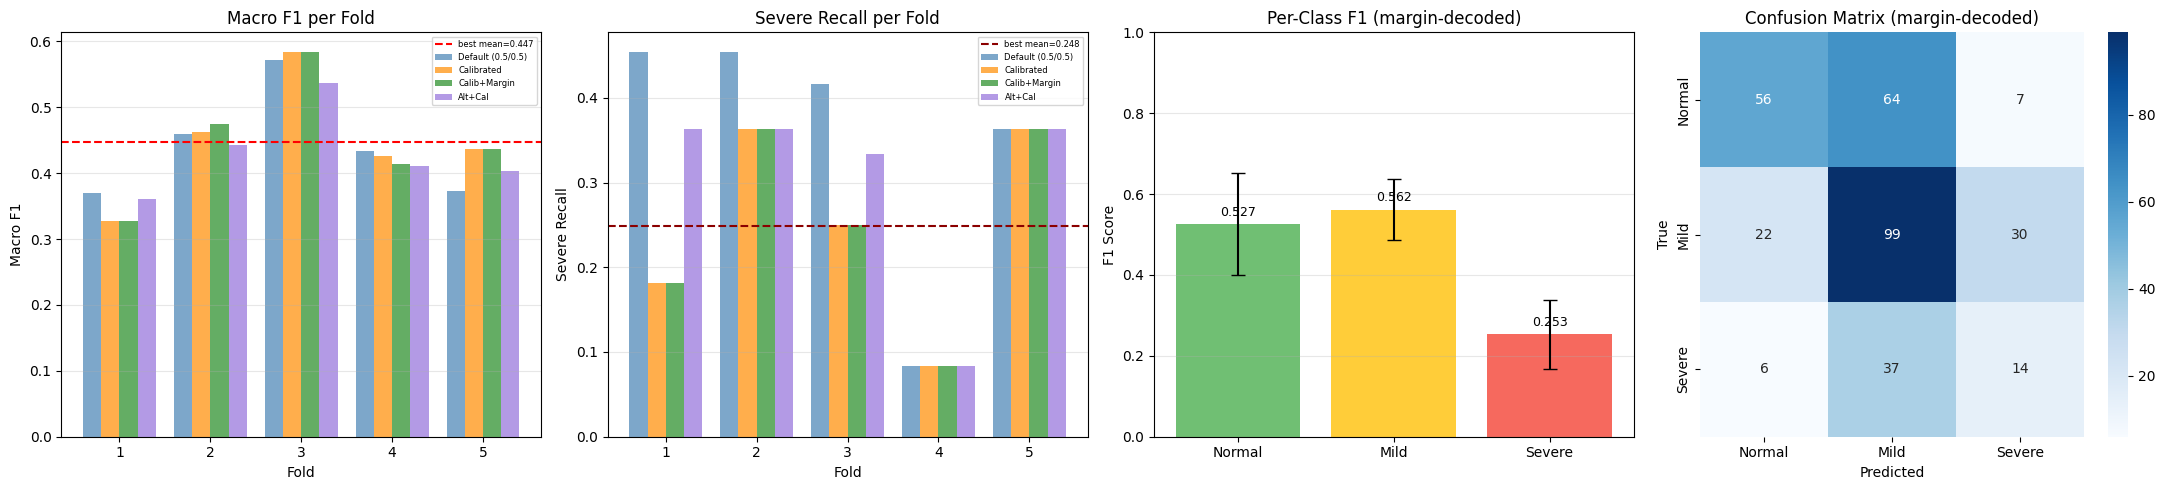


Done.


In [33]:
# ===================== AGGREGATE RESULTS ======================

def summarize_results(fold_list, label=""):
    """Print mean +/- std across folds for key metrics."""
    if not fold_list:
        print(f"\n  {label}: no results")
        return None, {}
    df = pd.DataFrame(fold_list)
    summary = {
        'accuracy':      f"{df['accuracy'].mean():.4f} +/- {df['accuracy'].std():.4f}",
        'balanced_acc':  f"{df['balanced_accuracy'].mean():.4f} +/- {df['balanced_accuracy'].std():.4f}",
        'macro_f1':      f"{df['macro_f1'].mean():.4f} +/- {df['macro_f1'].std():.4f}",
        'severe_recall': f"{df['severe_recall'].mean():.4f} +/- {df['severe_recall'].std():.4f}",
    }
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    for k, v in summary.items():
        print(f"  {k:20s} {v}")
    return df, summary


df_default, summary_default = summarize_results(
    all_fold_metrics,
    f"DEFAULT THRESHOLDS  [{CFG['aggregation']}]"
)

df_calib, summary_calib = summarize_results(
    all_fold_metrics_calib,
    f"CALIBRATED THRESHOLDS (no margin)  [{CFG['aggregation']}]"
)

df_margin, summary_margin = summarize_results(
    all_fold_metrics_margin,
    f"CALIBRATED + MARGIN DECODING  [{CFG['aggregation']}]"
)

alt_label = all_fold_metrics_alt[0]['aggregation'] if all_fold_metrics_alt else "?"
df_alt, summary_alt = summarize_results(
    all_fold_metrics_alt,
    f"ALT AGGREGATION + CALIBRATED  [{alt_label}]"
)

# ===================== PER-CLASS DETAIL =======================
# Show per-class for the best available mode: margin > calib > default
best_source_label = "default"
if all_fold_metrics_margin:
    metric_source = all_fold_metrics_margin
    best_source_label = "margin-decoded"
elif all_fold_metrics_calib:
    metric_source = all_fold_metrics_calib
    best_source_label = "calibrated"
else:
    metric_source = all_fold_metrics

print(f"\n{'='*60}")
print(f"  Per-class recall ({best_source_label}, per fold)")
print(f"{'='*60}")
for m in metric_source:
    recs = m['per_class_recall']
    thresh_info = m.get('thresholds', 'default')
    print(f"  Fold {m['fold']}: Normal={recs[0]:.3f}  Mild={recs[1]:.3f}  "
          f"Severe={recs[2]:.3f}  [{thresh_info}]")

per_class_f1_arr = np.array([m['per_class_f1'] for m in metric_source])
print(f"\n  Mean per-class F1:  Normal={per_class_f1_arr[:,0].mean():.3f}  "
      f"Mild={per_class_f1_arr[:,1].mean():.3f}  Severe={per_class_f1_arr[:,2].mean():.3f}")

per_class_rec_arr = np.array([m['per_class_recall'] for m in metric_source])
print(f"  Mean per-class Recall: Normal={per_class_rec_arr[:,0].mean():.3f}  "
      f"Mild={per_class_rec_arr[:,1].mean():.3f}  Severe={per_class_rec_arr[:,2].mean():.3f}")

# ===================== SAVE RESULTS ===========================
results = {
    'experiment':  'curriculum_margin_balanced',
    'timestamp':   datetime.now().isoformat(),
    'config':      {k: str(v) if isinstance(v, (list, dict)) else v for k, v in CFG.items()},
    'default_summary':      summary_default,
    'calibrated_summary':   summary_calib,
    'margin_summary':       summary_margin,
    'alternative_summary':  summary_alt,
    'per_fold_default':     all_fold_metrics,
    'per_fold_calibrated':  all_fold_metrics_calib,
    'per_fold_margin':      all_fold_metrics_margin,
    'per_fold_alternative': all_fold_metrics_alt,
}

with open(OUTPUT_DIR / 'curriculum_cv_results.json', 'w') as f:
    json.dump(results, f, indent=2, default=str)
print(f"\nResults saved -> {OUTPUT_DIR / 'curriculum_cv_results.json'}")

# ===================== VISUALIZATION ==========================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# 1. Fold-wise macro-F1: comparison across modes
dfs_plot = [
    (df_default, 'Default (0.5/0.5)', 'steelblue'),
    (df_calib,   'Calibrated',        'darkorange'),
    (df_margin,  'Calib+Margin',      'forestgreen'),
    (df_alt,     'Alt+Cal',           'mediumpurple'),
]
n_modes = sum(1 for d, _, _ in dfs_plot if d is not None)
width = 0.8 / max(n_modes, 1)
offset = 0
for df_p, lbl, col in dfs_plot:
    if df_p is not None:
        axes[0].bar(df_p['fold'] + offset - 0.3, df_p['macro_f1'],
                    width=width, alpha=0.7, label=lbl, color=col)
        offset += width
best_df = df_margin if df_margin is not None else df_calib if df_calib is not None else df_default
if best_df is not None:
    axes[0].axhline(best_df['macro_f1'].mean(), color='r', ls='--',
                    label=f"best mean={best_df['macro_f1'].mean():.3f}")
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Macro F1 per Fold')
axes[0].legend(fontsize=6)
axes[0].grid(axis='y', alpha=0.3)

# 2. Severe recall across modes
offset = 0
for df_p, lbl, col in dfs_plot:
    if df_p is not None:
        axes[1].bar(df_p['fold'] + offset - 0.3, df_p['severe_recall'],
                    width=width, alpha=0.7, label=lbl, color=col)
        offset += width
if best_df is not None:
    axes[1].axhline(best_df['severe_recall'].mean(), color='darkred', ls='--',
                    label=f"best mean={best_df['severe_recall'].mean():.3f}")
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Severe Recall')
axes[1].set_title('Severe Recall per Fold')
axes[1].legend(fontsize=6)
axes[1].grid(axis='y', alpha=0.3)

# 3. Per-class mean F1 bar chart (best mode)
class_f1_mean = per_class_f1_arr.mean(axis=0)
class_f1_std  = per_class_f1_arr.std(axis=0)
bars = axes[2].bar(CLASS_NAMES, class_f1_mean, yerr=class_f1_std,
                   color=['#4CAF50', '#FFC107', '#F44336'], alpha=0.8, capsize=5)
for bar, val in zip(bars, class_f1_mean):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=9)
axes[2].set_ylabel('F1 Score')
axes[2].set_title(f'Per-Class F1 ({best_source_label})')
axes[2].set_ylim(0, 1.0)
axes[2].grid(axis='y', alpha=0.3)

# 4. Confusion matrix (best mode)
total_cm = np.zeros((3, 3), dtype=int)
for m in metric_source:
    total_cm += np.array(m['confusion_matrix'])
sns.heatmap(total_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[3])
axes[3].set_title(f'Confusion Matrix ({best_source_label})')
axes[3].set_ylabel('True')
axes[3].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'curriculum_cv_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDone.")

In [34]:
# =====================================================================
#  SANITY CHECK: Channel stats + boundary diagnostics (last fold)
# =====================================================================

print("="*70)
print("  CHANNEL STATISTICS  (last fold, pre-norm train windows)")
print("="*70)

# Regenerate UN-normalised windows for the last fold's train set
X_raw, y_raw, _ = make_windows(
    train_rids, signal_data, patient_df,
    segment="step3", window_len=WINDOW_LEN, augment=False,
)
ch_names = ["FHR", "UC"]
if CFG.get('use_slow_slope', False):
    ch_names.append(f"dFHR_{CFG.get('slow_slope_lag', 30)}s")
elif CFG.get('use_delta_channels', False):
    ch_names.extend(["ΔFHR", "ΔUC"])

for ch_idx in range(X_raw.shape[1]):
    vals = X_raw[:, ch_idx, :, 0].ravel()
    name = ch_names[ch_idx] if ch_idx < len(ch_names) else f"ch{ch_idx}"
    print(f"  {name:>10s}:  min={vals.min():8.2f}  max={vals.max():8.2f}  "
          f"mean={vals.mean():8.2f}  std={vals.std():8.2f}")

# Post-normalisation stats (from the pipeline's last fold)
print(f"\n  Post-norm stats (pipeline norm_stats):")
print(f"    mean = {norm_stats['mean']}")
print(f"    std  = {norm_stats['std']}")
for ch_idx in range(X_te.shape[1]):
    vals = X_te[:, ch_idx, :, 0].ravel()
    name = ch_names[ch_idx] if ch_idx < len(ch_names) else f"ch{ch_idx}"
    print(f"  {name:>10s} (normed):  min={vals.min():8.2f}  max={vals.max():8.2f}  "
          f"mean={vals.mean():8.2f}  std={vals.std():8.2f}")

# ── Boundary output diagnostics ──
print(f"\n{'='*70}")
print("  BOUNDARY OUTPUTS BY CLASS  (last fold, test set)")
print("="*70)

raw_logits = model.predict(X_te, verbose=0)
p_a = 1.0 / (1.0 + np.exp(-raw_logits[:, 0]))  # P(y >= Mild)
p_b = 1.0 / (1.0 + np.exp(-raw_logits[:, 1]))  # P(y >= Severe)

print(f"  {'Class':>10s}  {'N_win':>6s}  {'P(y≥Mild)':>12s}  {'P(y≥Severe)':>12s}")
print(f"  {'-'*50}")
for cls_id, cls_name in enumerate(CLASS_NAMES):
    mask = (y_te == cls_id)
    n = mask.sum()
    if n > 0:
        ma = p_a[mask].mean()
        mb = p_b[mask].mean()
        print(f"  {cls_name:>10s}  {n:6d}  {ma:12.4f}  {mb:12.4f}")

# Expected: Normal < Mild < Severe for both P(y≥Mild) and P(y≥Severe)
gap_a = p_a[y_te == 2].mean() - p_a[y_te == 0].mean()
gap_b = p_b[y_te == 2].mean() - p_b[y_te == 0].mean()
print(f"\n  Severe-Normal gap:  ΔP(y≥Mild)={gap_a:.4f}  ΔP(y≥Severe)={gap_b:.4f}")
mono_a = p_a[y_te == 0].mean() < p_a[y_te == 1].mean() < p_a[y_te == 2].mean()
mono_b = p_b[y_te == 0].mean() < p_b[y_te == 1].mean() < p_b[y_te == 2].mean()
print(f"  Monotonic P(y≥Mild): {'✓' if mono_a else '✗'}   "
      f"Monotonic P(y≥Severe): {'✓' if mono_b else '✗'}")

del X_raw, y_raw
print("\nDone.")

  CHANNEL STATISTICS  (last fold, pre-norm train windows)
         FHR:  min=   28.45  max=  266.60  mean=  128.42  std=   23.98
          UC:  min=    0.30  max=  127.00  mean=   21.72  std=   23.53
    dFHR_30s:  min= -160.40  max=  214.60  mean=   -0.27  std=   22.56

  Post-norm stats (pipeline norm_stats):
    mean = [128.42113     21.723305    -0.26784083]
    std  = [23.984882 23.529776 22.563143]
         FHR (normed):  min=   -4.12  max=    4.58  mean=    0.29  std=    0.85
          UC (normed):  min=   -0.91  max=    4.47  mean=    0.03  std=    0.94
    dFHR_30s (normed):  min=   -6.43  max=    6.18  mean=    0.01  std=    0.76

  BOUNDARY OUTPUTS BY CLASS  (last fold, test set)
       Class   N_win     P(y≥Mild)   P(y≥Severe)
  --------------------------------------------------
      Normal     164        0.6206        0.3511
        Mild     193        0.7676        0.5100
      Severe      71        0.7519        0.6077

  Severe-Normal gap:  ΔP(y≥Mild)=0.1313  ΔP(y≥Seve

## 16. Uncertainty & Confidence Analysis

**Why this matters academically:** Mild is the most ambiguous class (inter-annotator disagreement is highest there). A good dissertation shows *why* the model struggles — not just that it does.

Analysis:
1. **Per-class prediction entropy** — Mild predictions should have higher entropy (more uncertain)
2. **Confidence calibration** — Are high-confidence predictions actually correct?
3. **Confusion neighbourhood** — How often does Mild get pulled toward Normal vs Severe?

This supports the ordinal interpretation: Mild sits on the decision boundary between two cleaner classes.

  Per-class prediction entropy (window-level)
  Normal  : mean=0.6572  std=0.2573  median=0.6907  n=164
  Mild    : mean=0.6106  std=0.2660  median=0.6517  n=193
  Severe  : mean=0.5627  std=0.3090  median=0.6388  n=71


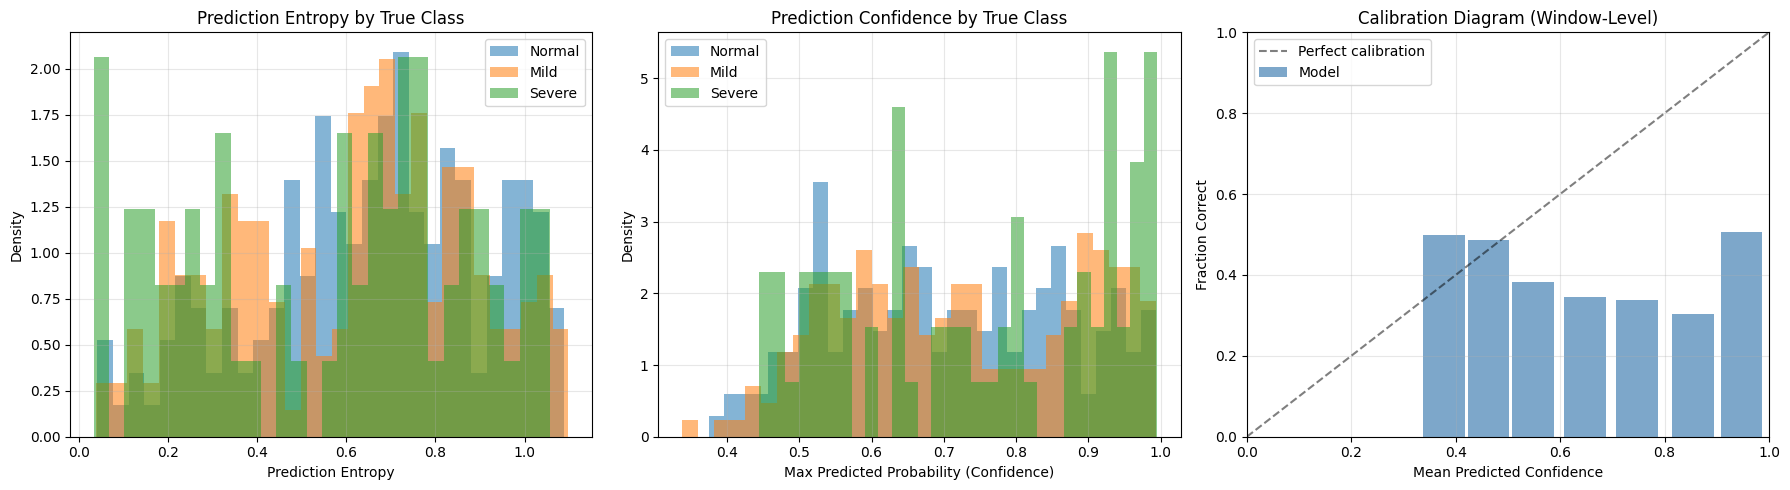


  Expected Calibration Error (ECE): 0.3350

  Two-Boundary Head Diagnostics (window-level)
  Normal  : P(y≥Mild) mean=0.6206±0.3118  P(y≥Severe) mean=0.3511±0.3379  n=164
  Mild    : P(y≥Mild) mean=0.7676±0.2302  P(y≥Severe) mean=0.5100±0.3726  n=193
  Severe  : P(y≥Mild) mean=0.7519±0.2578  P(y≥Severe) mean=0.6077±0.3527  n=71

  Mild confusion neighbourhood (window-level, last fold)
  True-Mild predicted as Normal: 18.1%  (35/193)
  True-Mild predicted as Mild: 30.6%  (59/193)
  True-Mild predicted as Severe: 51.3%  (99/193)

  Mean probability vector for true-Mild windows:
    P(Normal) = 0.2324
    P(Mild) = 0.2881
    P(Severe) = 0.4795

  Record-level mean entropy (last fold)
  Normal  : mean_entropy=0.6550 ± 0.1851  (n=26 records)
  Mild    : mean_entropy=0.6012 ± 0.1884  (n=30 records)
  Severe  : mean_entropy=0.5593 ± 0.2237  (n=11 records)

Uncertainty analysis complete.


In [35]:
# =====================================================================
#  UNCERTAINTY & CONFIDENCE ANALYSIS  (last fold's model & test data)
# =====================================================================

from scipy.stats import entropy as sp_entropy

# ── 1. Collect per-window probabilities & true labels ──────────────
raw_preds = model.predict(X_te, verbose=0)
if use_two_boundary:
    window_probs = two_boundary_logits_to_probs(raw_preds).numpy()
    # Also extract raw boundary probabilities for diagnostics
    _logits = raw_preds if isinstance(raw_preds, np.ndarray) else raw_preds.numpy()
    _p_a = 1.0 / (1.0 + np.exp(-_logits[:, 0]))
    _p_b = 1.0 / (1.0 + np.exp(-_logits[:, 1]))
elif CFG['use_coral']:
    window_probs = coral_logits_to_probs(raw_preds).numpy()
    _p_a = _p_b = None
else:
    window_probs = raw_preds
    _p_a = _p_b = None

window_true = y_te   # integer labels per window
window_pred = np.argmax(window_probs, axis=1)

# ── 2. Per-window prediction entropy ──────────────────────────────
window_entropy = sp_entropy(window_probs.T + 1e-12)   # base-e

# ── 3. Per-class entropy distribution ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3a. Entropy histogram by TRUE class
ax = axes[0]
for cls_id, cls_name in enumerate(CLASS_NAMES):
    mask = window_true == cls_id
    if mask.sum() == 0:
        continue
    ax.hist(window_entropy[mask], bins=30, alpha=0.55, label=cls_name, density=True)
ax.set_xlabel('Prediction Entropy')
ax.set_ylabel('Density')
ax.set_title('Prediction Entropy by True Class')
ax.legend()
ax.grid(alpha=0.3)

# Summary stats
print("="*60)
print("  Per-class prediction entropy (window-level)")
print("="*60)
for cls_id, cls_name in enumerate(CLASS_NAMES):
    mask = window_true == cls_id
    if mask.sum() == 0:
        print(f"  {cls_name}: no windows")
        continue
    e = window_entropy[mask]
    print(f"  {cls_name:8s}: mean={e.mean():.4f}  std={e.std():.4f}  "
          f"median={np.median(e):.4f}  n={mask.sum()}")

# 3b. Confidence (max prob) by TRUE class
window_confidence = window_probs.max(axis=1)
ax = axes[1]
for cls_id, cls_name in enumerate(CLASS_NAMES):
    mask = window_true == cls_id
    if mask.sum() == 0:
        continue
    ax.hist(window_confidence[mask], bins=30, alpha=0.55, label=cls_name, density=True)
ax.set_xlabel('Max Predicted Probability (Confidence)')
ax.set_ylabel('Density')
ax.set_title('Prediction Confidence by True Class')
ax.legend()
ax.grid(alpha=0.3)

# 3c. Calibration: binned accuracy vs confidence
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_accs, bin_confs, bin_counts = [], [], []
correct = (window_pred == window_true).astype(float)

for i in range(n_bins):
    in_bin = (window_confidence >= bin_edges[i]) & (window_confidence < bin_edges[i+1])
    if in_bin.sum() == 0:
        continue
    bin_accs.append(correct[in_bin].mean())
    bin_confs.append(window_confidence[in_bin].mean())
    bin_counts.append(int(in_bin.sum()))

ax = axes[2]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.bar(bin_confs, bin_accs, width=0.08, alpha=0.7, color='steelblue',
       label='Model')
ax.set_xlabel('Mean Predicted Confidence')
ax.set_ylabel('Fraction Correct')
ax.set_title('Calibration Diagram (Window-Level)')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'uncertainty_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 4. Expected Calibration Error (ECE) ──────────────────────────
ece = sum(
    abs(a - c) * n for a, c, n in zip(bin_accs, bin_confs, bin_counts)
) / max(sum(bin_counts), 1)
print(f"\n  Expected Calibration Error (ECE): {ece:.4f}")

# ── 5. Two-boundary diagnostics ─────────────────────────────────
if use_two_boundary and _p_a is not None:
    print("\n" + "="*60)
    print("  Two-Boundary Head Diagnostics (window-level)")
    print("="*60)
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        mask = window_true == cls_id
        if mask.sum() == 0:
            continue
        print(f"  {cls_name:8s}: P(y≥Mild) mean={_p_a[mask].mean():.4f}±{_p_a[mask].std():.4f}  "
              f"P(y≥Severe) mean={_p_b[mask].mean():.4f}±{_p_b[mask].std():.4f}  n={mask.sum()}")

# ── 6. Confusion neighbourhood: where does Mild go? ─────────────
print("\n" + "="*60)
print("  Mild confusion neighbourhood (window-level, last fold)")
print("="*60)
mild_mask = window_true == 1
if mild_mask.sum() > 0:
    mild_preds = window_pred[mild_mask]
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        frac = (mild_preds == cls_id).mean()
        print(f"  True-Mild predicted as {cls_name}: {frac:.1%}  "
              f"({(mild_preds == cls_id).sum()}/{len(mild_preds)})")

    mild_mean_probs = window_probs[mild_mask].mean(axis=0)
    print(f"\n  Mean probability vector for true-Mild windows:")
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        print(f"    P({cls_name}) = {mild_mean_probs[cls_id]:.4f}")
else:
    print("  No Mild windows in last fold's test set.")

# ── 7. Record-level uncertainty ──────────────────────────────────
print("\n" + "="*60)
print("  Record-level mean entropy (last fold)")
print("="*60)

rec_entropy = defaultdict(list)
for i, rid in enumerate(rec_te):
    rec_entropy[rid].append(window_entropy[i])

rec_entropy_mean = {r: np.mean(v) for r, v in rec_entropy.items()}

for cls_id, cls_name in enumerate(CLASS_NAMES):
    cls_recs = [r for r in rec_entropy_mean
                if r in y_true_rec and y_true_rec[r] == cls_id]
    if cls_recs:
        ents = [rec_entropy_mean[r] for r in cls_recs]
        print(f"  {cls_name:8s}: mean_entropy={np.mean(ents):.4f} ± {np.std(ents):.4f}  "
              f"(n={len(cls_recs)} records)")

print("\nUncertainty analysis complete.")

## 17. Temperature Scaling (Post-Hoc Calibration)

**Why:** Even after threshold tuning, the model's boundary probabilities can be overconfident (high ECE). Temperature scaling learns a single scalar $T > 0$ that softens logits: $\hat{p} = \sigma(z / T)$. This improves probability reliability without changing the ranking of predictions.

Applied **per-fold** on the inner-val logits, then used to re-decode the test set.

In [36]:
# =====================================================================
#  TEMPERATURE SCALING  — per-fold post-hoc calibration
# =====================================================================
from scipy.optimize import minimize_scalar

def fit_temperature(val_logits_dict, patient_df, boundary='both'):
    """
    Learn temperature T that minimises NLL on validation boundary logits.

    For two-boundary models:
      - boundary='a': calibrate only logit_a (P(y≥Mild))
      - boundary='b': calibrate only logit_b (P(y≥Severe))
      - boundary='both': shared T for both (default — more stable)

    Parameters
    ----------
    val_logits_dict : dict[rec_id -> np.array (2,)]
    patient_df      : DataFrame with rec_id, step3_label

    Returns
    -------
    T : float  (temperature, typically > 1 means model was overconfident)
    """
    rids = []
    logits_a, logits_b = [], []
    targets_a, targets_b = [], []

    for rid, logit in val_logits_dict.items():
        row = patient_df[patient_df['rec_id'] == rid]
        if row.empty:
            continue
        label = int(row['step3_label'].iloc[0])
        rids.append(rid)
        logits_a.append(logit[0])
        logits_b.append(logit[1])
        targets_a.append(float(label >= 1))
        targets_b.append(float(label >= 2))

    logits_a = np.array(logits_a)
    logits_b = np.array(logits_b)
    targets_a = np.array(targets_a)
    targets_b = np.array(targets_b)

    def nll(T):
        """Negative log-likelihood with temperature T."""
        T = max(T, 0.01)  # prevent division by zero
        loss = 0.0
        if boundary in ('a', 'both'):
            p = 1.0 / (1.0 + np.exp(-logits_a / T))
            p = np.clip(p, 1e-7, 1 - 1e-7)
            loss += -np.mean(targets_a * np.log(p) + (1 - targets_a) * np.log(1 - p))
        if boundary in ('b', 'both'):
            p = 1.0 / (1.0 + np.exp(-logits_b / T))
            p = np.clip(p, 1e-7, 1 - 1e-7)
            loss += -np.mean(targets_b * np.log(p) + (1 - targets_b) * np.log(1 - p))
        return loss

    result = minimize_scalar(nll, bounds=(0.1, 10.0), method='bounded')
    T_opt = result.x
    return T_opt


def apply_temperature(logits_dict, T):
    """Scale all record logits by temperature T."""
    return {rid: logit / T for rid, logit in logits_dict.items()}


# ── Apply temperature scaling to the saved CV results ────────────
# We use the ensemble-averaged val logits (already stored per fold
# in seed_val_logits) and test logits.
# Since the main loop has finished, we'll re-calibrate using the
# LAST fold's data as a demonstration, then show ECE improvement.

print("="*60)
print("  TEMPERATURE SCALING DEMO  (last fold)")
print("="*60)

# Fit T on val
T_opt = fit_temperature(avg_val_logits, patient_df, boundary='both')
print(f"  Fitted temperature T = {T_opt:.3f}")
if T_opt > 1.0:
    print(f"  → Model was overconfident (T>1 softens probabilities)")
elif T_opt < 1.0:
    print(f"  → Model was underconfident (T<1 sharpens probabilities)")

# Apply to test logits
scaled_test_logits = apply_temperature(avg_test_logits, T_opt)

# Decode with calibrated thresholds + temperature
if cal_thresholds is not None:
    preds_temp = decode_from_logits(scaled_test_logits,
                                    cal_thresholds[0], cal_thresholds[1],
                                    margin=cal_margin)
    eval_rids_t = [r for r in test_rids if r in preds_temp and r in y_true_rec]
    y_t = np.array([y_true_rec[r] for r in eval_rids_t])
    y_p = np.array([preds_temp[r] for r in eval_rids_t])

    from sklearn.metrics import classification_report
    print(f"\n  Temp-scaled + calibrated thresholds (tA={cal_thresholds[0]:.2f}, "
          f"tB={cal_thresholds[1]:.2f}, m={cal_margin:.2f}):")
    print(f"  accuracy={accuracy_score(y_t, y_p):.4f}  "
          f"balanced_acc={balanced_accuracy_score(y_t, y_p):.4f}  "
          f"macro_f1={f1_score(y_t, y_p, average='macro', zero_division=0):.4f}")

    _, rec_arr, _, _ = precision_recall_fscore_support(y_t, y_p, labels=[0,1,2], zero_division=0)
    print(f"  Per-class recall: Normal={rec_arr[0]:.3f}  Mild={rec_arr[1]:.3f}  "
          f"Severe={rec_arr[2]:.3f}")

# ── ECE before vs after temperature scaling ──────────────────────
def compute_ece(logits_dict, y_true_rec, T=1.0, n_bins=10):
    """Compute ECE on boundary probabilities after temperature scaling."""
    confs, corrects = [], []
    for rid, logit in logits_dict.items():
        if rid not in y_true_rec:
            continue
        label = y_true_rec[rid]
        # Convert to 3-class probs
        p_a = 1.0 / (1.0 + np.exp(-logit[0] / T))
        p_b = 1.0 / (1.0 + np.exp(-logit[1] / T))
        p_b = min(p_b, p_a)
        probs = np.array([1 - p_a, p_a - p_b, p_b])
        probs = np.maximum(probs, 1e-7)
        probs /= probs.sum()
        pred = np.argmax(probs)
        confs.append(probs[pred])
        corrects.append(int(pred == label))

    confs = np.array(confs)
    corrects = np.array(corrects)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (confs >= bin_edges[i]) & (confs < bin_edges[i+1])
        if in_bin.sum() == 0:
            continue
        ece += abs(corrects[in_bin].mean() - confs[in_bin].mean()) * in_bin.sum()
    return ece / max(len(confs), 1)

ece_before = compute_ece(avg_test_logits, y_true_rec, T=1.0)
ece_after  = compute_ece(avg_test_logits, y_true_rec, T=T_opt)
print(f"\n  ECE before temperature scaling: {ece_before:.4f}")
print(f"  ECE after  temperature scaling: {ece_after:.4f}")
print(f"  ECE improvement: {ece_before - ece_after:+.4f}")

print("\nTemperature scaling complete.")

  TEMPERATURE SCALING DEMO  (last fold)
  Fitted temperature T = 1.902
  → Model was overconfident (T>1 softens probabilities)

  Temp-scaled + calibrated thresholds (tA=0.60, tB=0.70, m=0.00):
  accuracy=0.4776  balanced_acc=0.4371  macro_f1=0.4366
  Per-class recall: Normal=0.538  Mild=0.500  Severe=0.273

  ECE before temperature scaling: 0.2712
  ECE after  temperature scaling: 0.1813
  ECE improvement: +0.0900

Temperature scaling complete.


In [37]:
# Quick summary — extract key numbers
import json
with open(OUTPUT_DIR / 'curriculum_cv_results.json') as f:
    res = json.load(f)

for mode in ['default_summary', 'calibrated_summary', 'margin_summary', 'alternative_summary']:
    print(f"\n{mode}:")
    for k, v in res.get(mode, {}).items():
        print(f"  {k}: {v}")


default_summary:
  accuracy: 0.4836 +/- 0.0936
  balanced_acc: 0.4516 +/- 0.0712
  macro_f1: 0.4418 +/- 0.0824
  severe_recall: 0.3545 +/- 0.1561

calibrated_summary:
  accuracy: 0.5045 +/- 0.0987
  balanced_acc: 0.4496 +/- 0.0837
  macro_f1: 0.4473 +/- 0.0922
  severe_recall: 0.2485 +/- 0.1207

margin_summary:
  accuracy: 0.5045 +/- 0.0981
  balanced_acc: 0.4491 +/- 0.0850
  macro_f1: 0.4472 +/- 0.0938
  severe_recall: 0.2485 +/- 0.1207

alternative_summary:
  accuracy: 0.4896 +/- 0.0727
  balanced_acc: 0.4419 +/- 0.0532
  macro_f1: 0.4309 +/- 0.0660
  severe_recall: 0.3015 +/- 0.1227
